### Task Description:
#### Train a ML method to recognize <font color=red> Plant Species & Fe deficiency</font> based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
- In the TXT file, you will find an experiment conducted on four different species (Cs = Cucumber, Sl = Tomato, Zm = Maize, Hv = Barley) grown under Fe-deficient conditions.
- Each row refers to a different plant, while the columns indicate the values at various wavelengths of the reflectance spectrum (from 400 to 1000 nm).
- The second column contains the plant species information ("Species": Cs is cucumber, Zm is maize, Sl is tomato, Hv is barley).
- The third column contains the treatment information ("Thesis": +N-Fe indicates iron deficiency, +N+Fe indicates iron sufficiency).

#### Methods
- <font color=red> Multi-class </font> Linear Logistic Regression + Linear SHAP
- <font color=red> Multi-class </font> Polynomial Logistic Regression
- <font color=red> Multi-class </font> Random Forest + Tree SHAP

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import shap
from sklearn.utils import shuffle

#### Load and Preprocess
- Drop the 'Leaf' column as it has the same value 'YL' for all rows
- Combine and Encode the <font color=red> ‘Species' and ‘Thesis' </font> columns (the ground-truth label)
- Separate the dataset into features and labels
- Check class imbalance in the whole dataset
- Check for missing values (there was none)
- Identify outliers using the IQR method ---> <font color=red> I did not drop them </font>
- Feature selection using Random Forest ---> <font color=red> 97 non-important features out of 204 </font>
- Scale the feature values (here, Columns) using Z-Score
##### <font color=red> Watch the reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions) for execution </font>

Unique elements in 'Combined_Target':
['+N+Fe_Cs' '+N-Fe_Cs' '+N+Fe_Sl' '+N-Fe_Sl' '+N+Fe_Hv' '+N-Fe_Hv'
 '+N+Fe_Zm' '+N-Fe_Zm']
Class Distribution:
Combined_Target
+N+Fe_Cs    18
+N-Fe_Cs    18
+N+Fe_Sl    18
+N-Fe_Sl    18
+N+Fe_Hv    18
+N-Fe_Hv    18
+N+Fe_Zm    18
+N-Fe_Zm    18
Name: count, dtype: int64


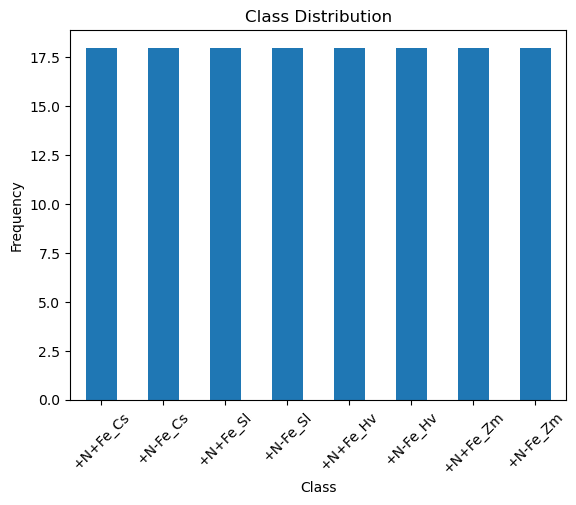

Columns with missing values: []

Outlier records/rows in the dataset:
Row numbers of outliers: [ 30  31  32  33  34  35  91  92  93  94  95  96  97  98  99 101 104 105
 106 107 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143]

Number of features with 0.0 importance: 97
Features with 0.0 importance: ['X400.20', 'X411.74', 'X417.52', 'X423.29', 'X426.19', 'X440.66', 'X481.32', 'X490.06', 'X504.64', 'X510.48', 'X513.40', 'X516.33', 'X528.03', 'X533.89', 'X539.75', 'X542.68', 'X548.55', 'X551.49', 'X557.36', 'X563.24', 'X566.18', 'X569.12', 'X589.75', 'X592.70', 'X604.51', 'X607.46', 'X616.34', 'X619.30', 'X637.08', 'X643.01', 'X675.73', 'X681.69', 'X687.65', 'X690.64', 'X705.57', 'X720.54', 'X729.53', 'X732.53', 'X735.53', 'X741.53', 'X747.54', 'X750.54', 'X759.56', 'X762.57', 'X768.60', 'X771.61', 'X774.62', 'X777.64', 'X780.65', 'X783.67', 'X786.68', 'X792.72', 'X795.74', 'X801.79', 'X804.81', 'X810.86', 'X816.92', 'X826.01', 'X829.04', 'X832.07', 'X838.14', 'X8

In [8]:
# Load the dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Drop the 'Leaf' column
data = data.drop(columns=['Leaf'])
# Separate features
X = data.iloc[:, 3:]
feature_names = X.columns.tolist()
# Combine 'Thesis' (iron deficiency) and 'Species' (plant type) into a single target column
data['Combined_Target'] = data['Thesis'].astype(str) + '_' + data['Species'].astype(str)
unique_elements = data['Combined_Target'].unique()
print("Unique elements in 'Combined_Target':")
print(unique_elements)
# Encode the combined target
le = LabelEncoder()
y = le.fit_transform(data['Combined_Target'])
# Check the distribution of the new target variable
class_distribution = data['Combined_Target'].value_counts()
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")
# IQR (identify rows where at least one feature (column) has an outlier)------------------>??
print("\nOutlier records/rows in the dataset:")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
# Print row numbers of the outliers
outlier_rows = np.where(outliers)[0]
print("Row numbers of outliers:", outlier_rows)
# print(X[outliers])

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
X_reduced = X.drop(columns=zero_importance_features)
feature_names_reduced = X_reduced .columns.tolist()
print("\nX_reduced.shape is ", X_reduced.shape)
print("\nX_reduced names.shape is ", len(feature_names_reduced))
#Scale the feature/columns values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
# X_scaled = scaler.fit_transform(X)

#### The following cell is related to "train & test" split which is under discussion
- Plan A: Blindly trust "train_test_split()" function
- Plan B: Manually, decompose the dataset based on plant type, Shuffle and Split (75% for Train and 25% for Test) Within Each Plant Species and 2) Combine the Splits
- Plan C: <font color=red> 1) Use the train_test_split function to shuffle and split the data for each plant species separately. The split is set to 75% for training and 25% for testing  each plant species has its own shuffled and split data, 2) Combine the Splits: combine the training subsets of (1) into a single training set and the test subsets into a single test set. </font>

In [9]:
# Step 3: Train-Test Split

#Plan A
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.25, random_state=42)


# Common between plan B&C
# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}


# Plan C
# ...
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []
# Iterate over each plant species
for plant in plant_groups_scaled.keys():
    X = plant_groups_scaled[plant][0]
    y = plant_groups_scaled[plant][1]
    
    # Split the data for each plant species (e.g., 75% train, 25% test)
    X_train_plant, X_test_plant, y_train_plant, y_test_plant = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
    
    # Append to the respective lists
    X_train_list.append(X_train_plant)
    y_train_list.append(y_train_plant)
    X_test_list.append(X_test_plant)
    y_test_list.append(y_test_plant)

# Concatenate the lists to form the final train and test sets
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)
# Shuffle the train and test sets to remove any order-based bias
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")



X_train shape: (108, 107), y_train shape: (108,)
X_test shape: (36, 107), y_test shape: (36,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Polynomial Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validationr in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> <font color=red> Multi-Class </font>  Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.712987        0.062488   
1          0.703896        0.069297   
2          0.703463        0.087805   
3          0.722511        0.088086   
4          0.842857        0.020286   
5          0.842857        0.020286   
6          0.834199        0.044266   
7          0.825108        0.050806   
8          0.935498        0.021576   
9          0.926407        0.035724   
10         0.926407        0.035724   
11         0.917316        0.033094   
12         0.953680        0.028768   
13         0.972294        0.022635   
14         0.954113        0.028761   
15         0.935931        0.036157   
16         0.962771        0.018640   
17         0.963203        0.034142   
18         0.963203        0.034142   
19         0.945022        0.033910   

                                            

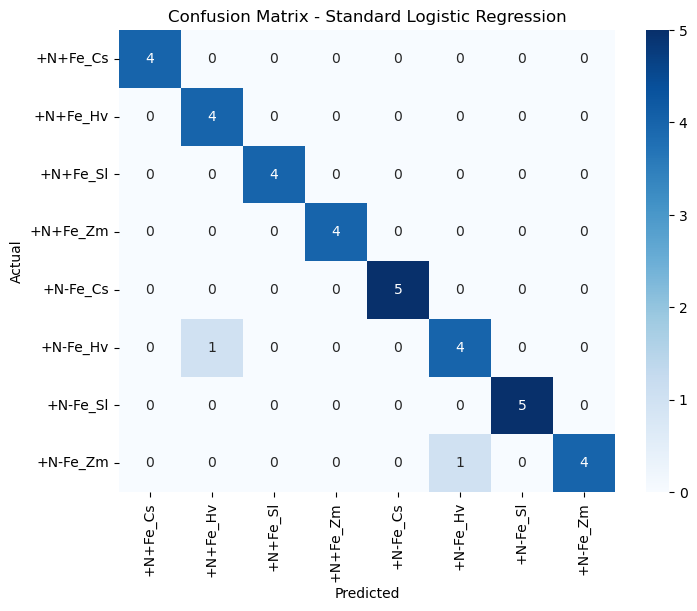

(36, 107, 8)
Generating SHAP plots for Class: +N+Fe_Cs


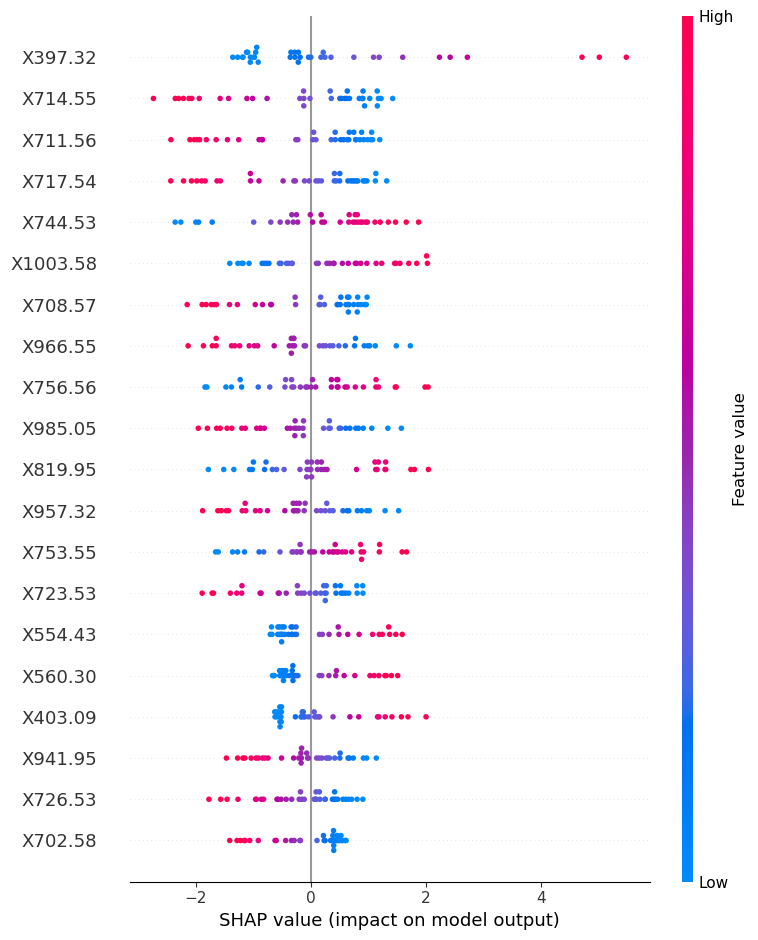

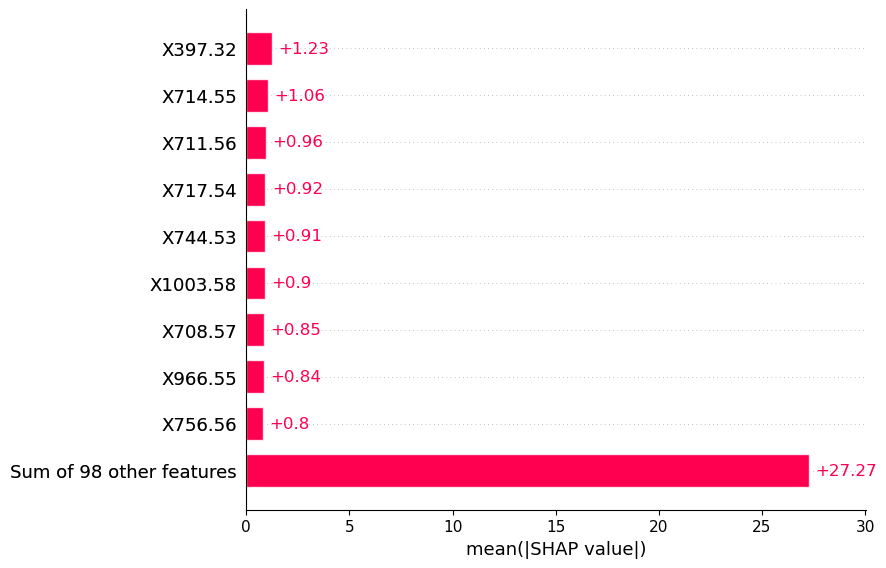

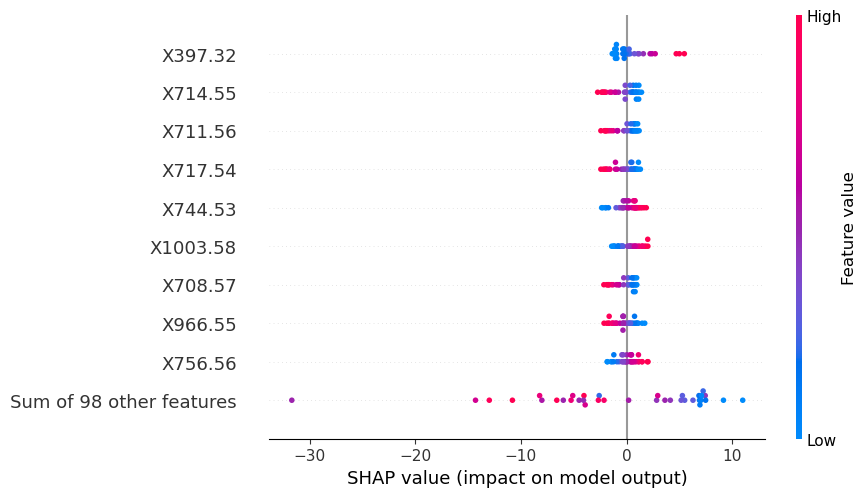

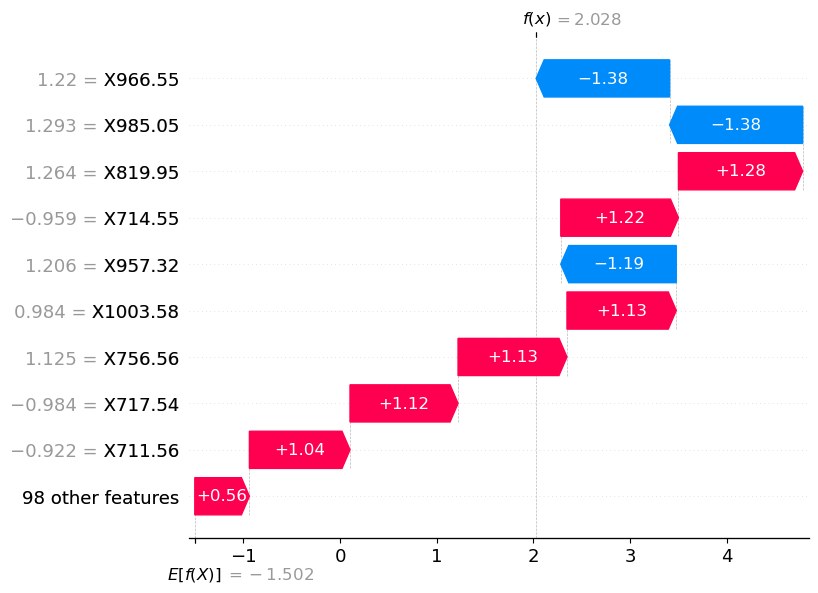

Generating SHAP plots for Class: +N+Fe_Hv


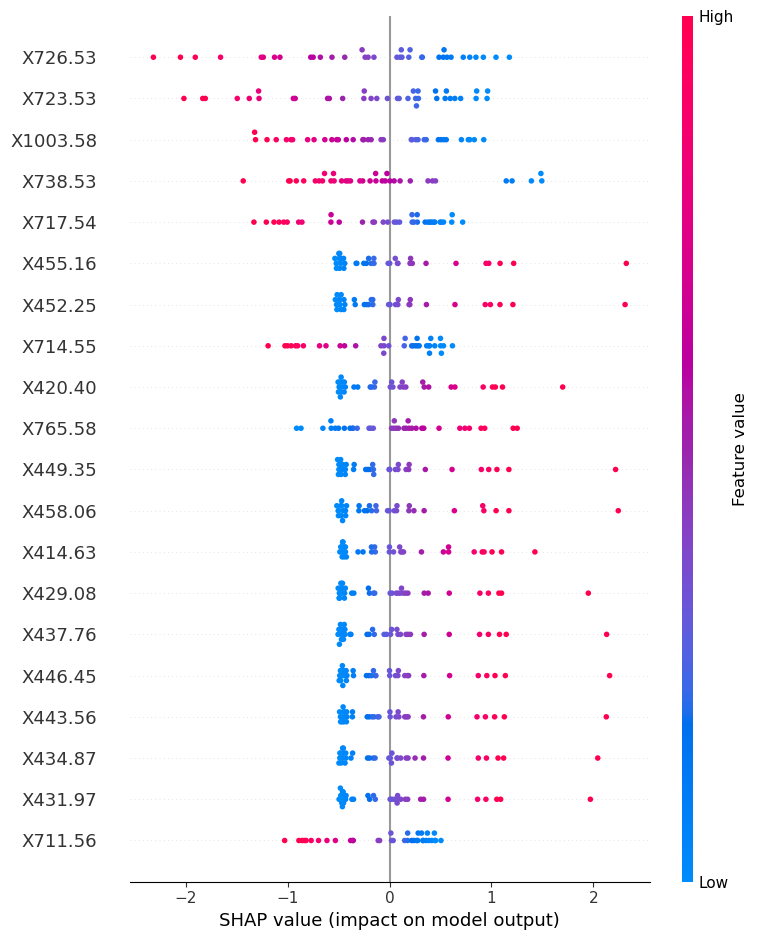

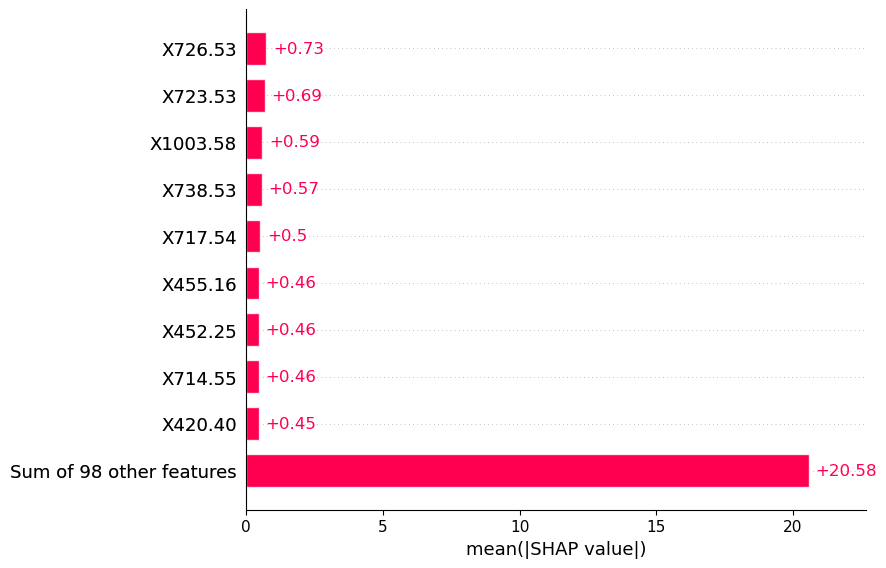

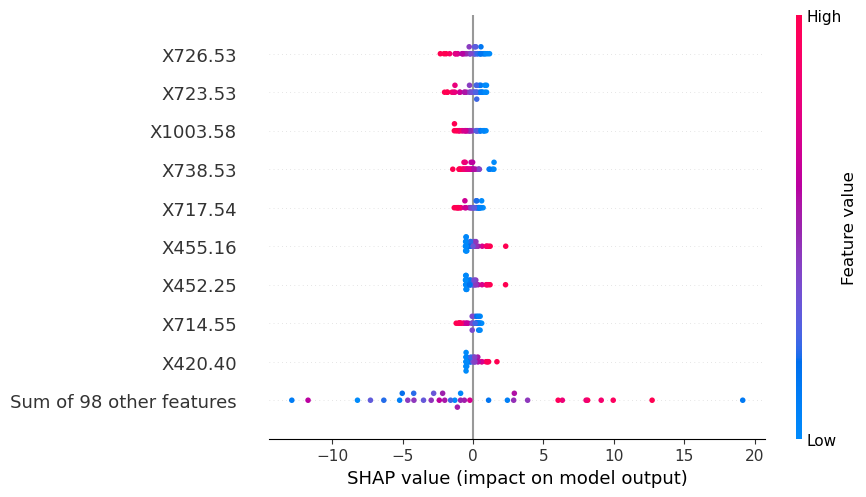

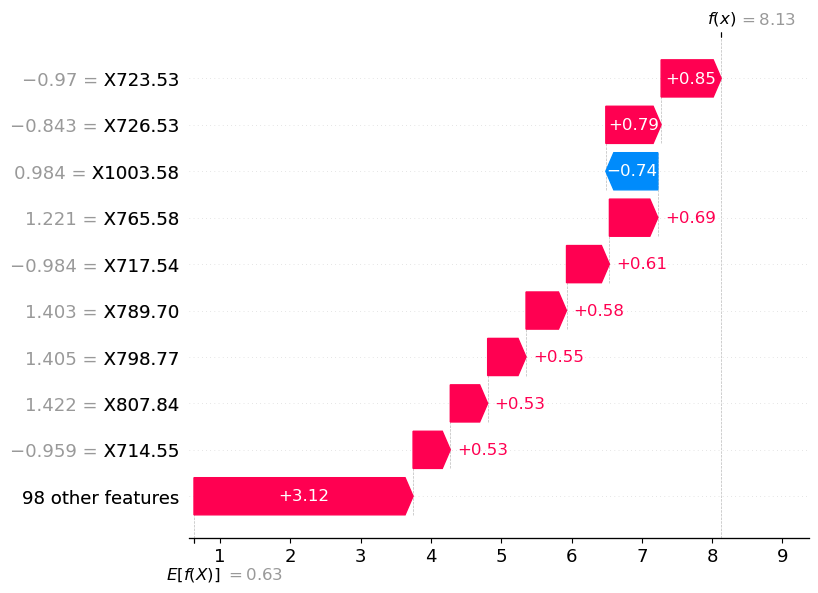

Generating SHAP plots for Class: +N+Fe_Sl


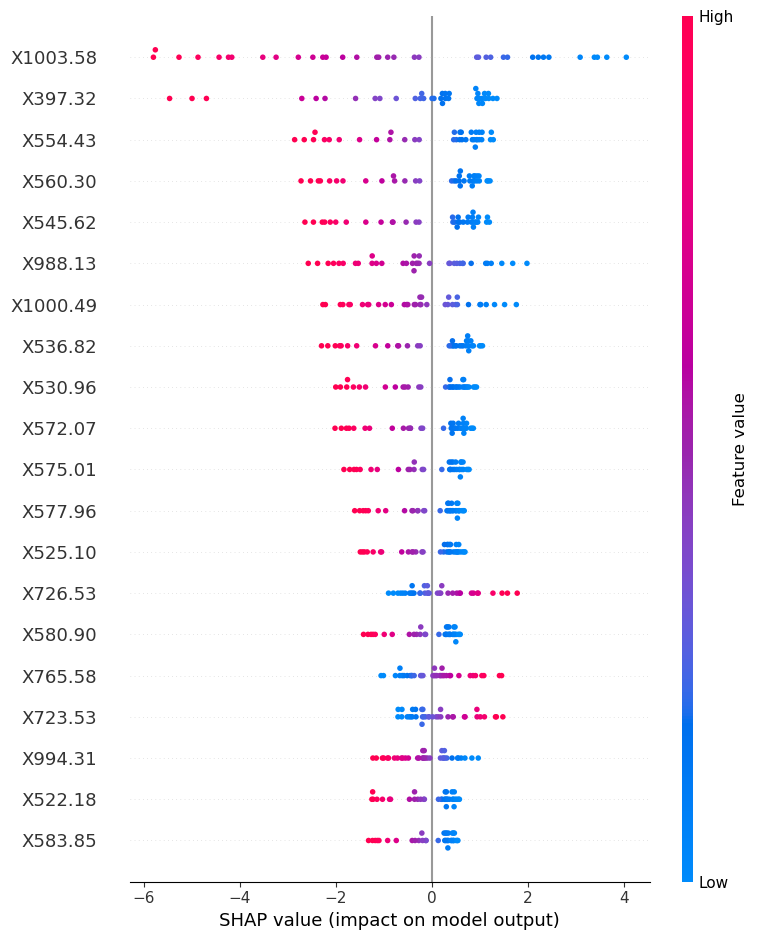

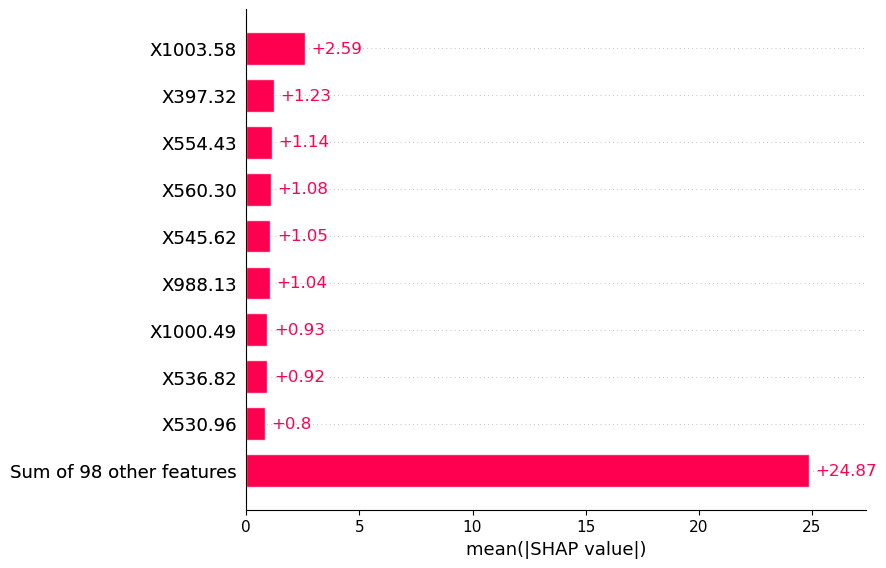

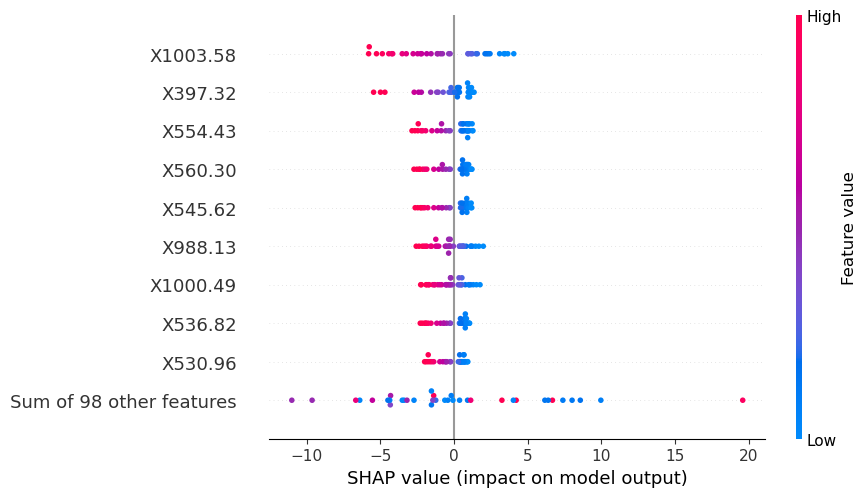

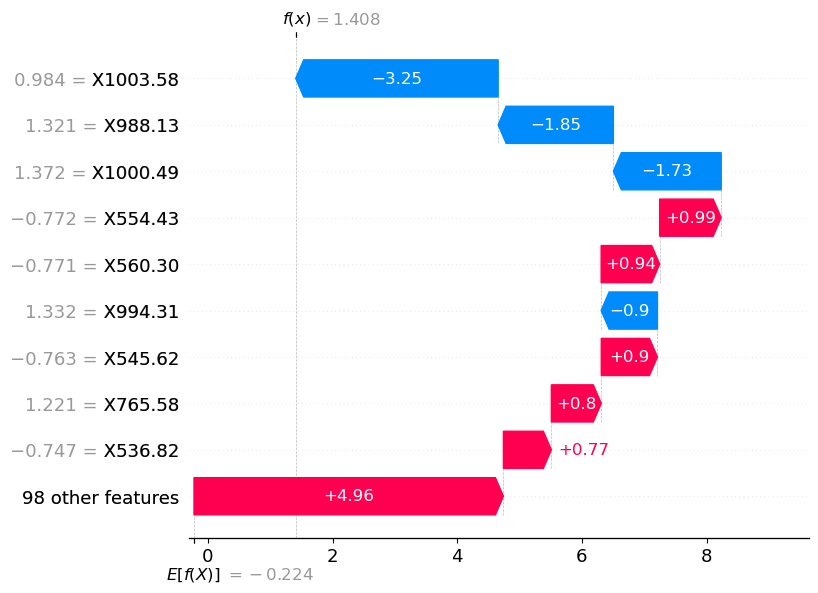

Generating SHAP plots for Class: +N+Fe_Zm


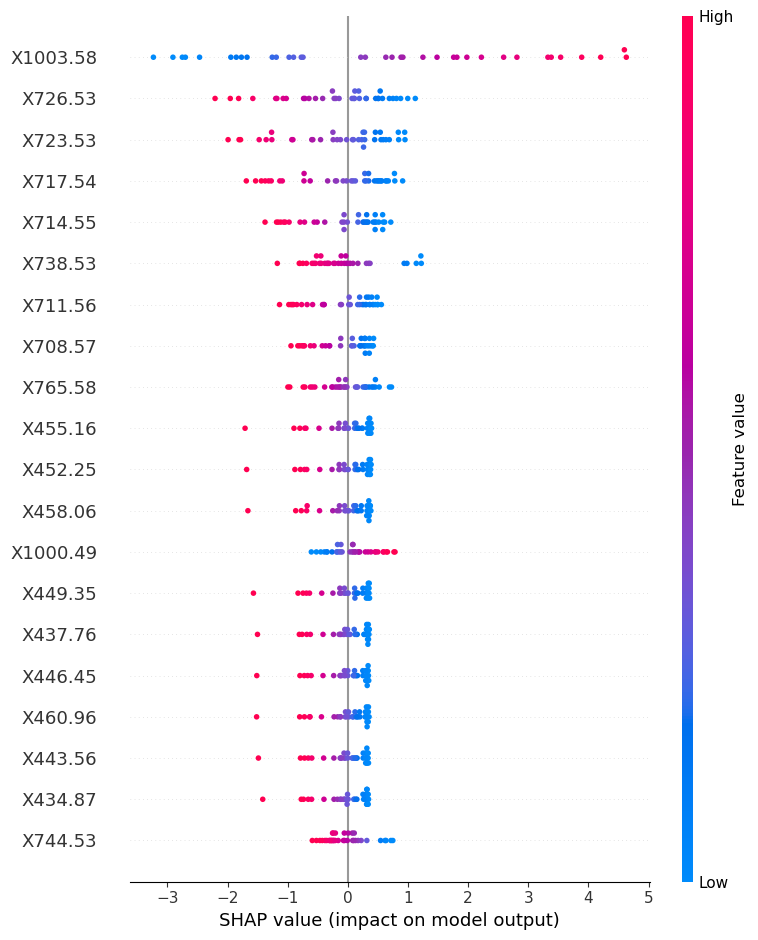

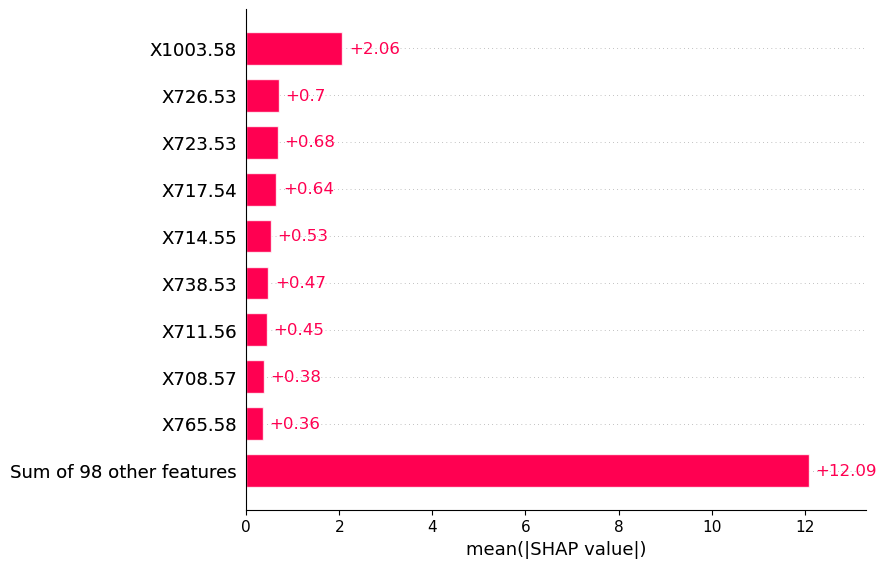

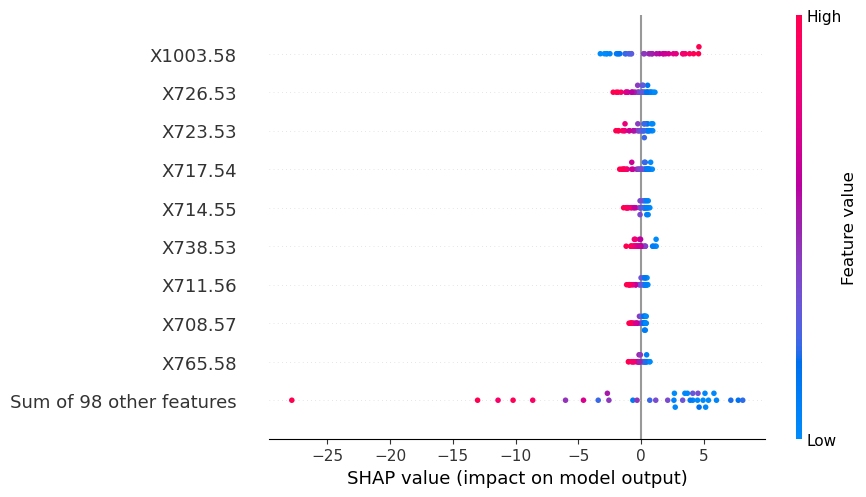

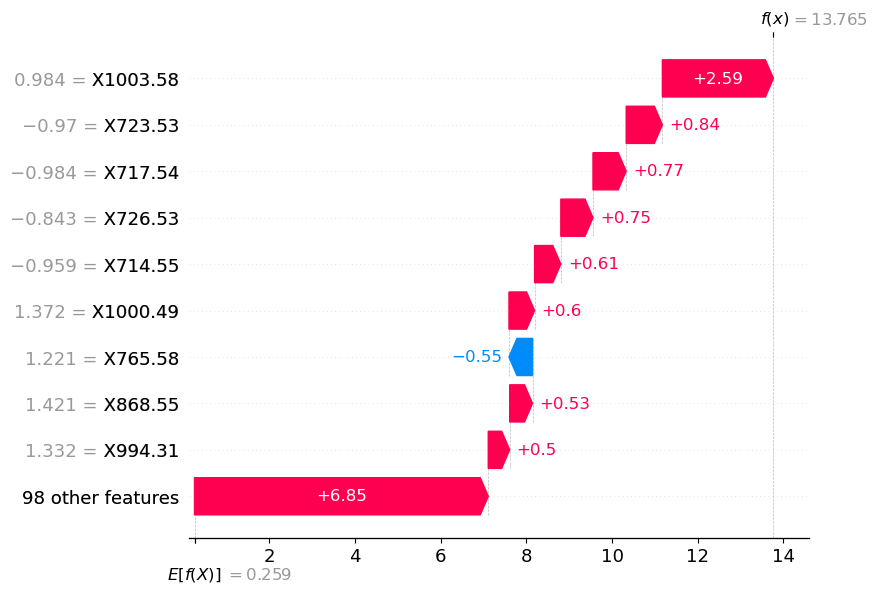

Generating SHAP plots for Class: +N-Fe_Cs


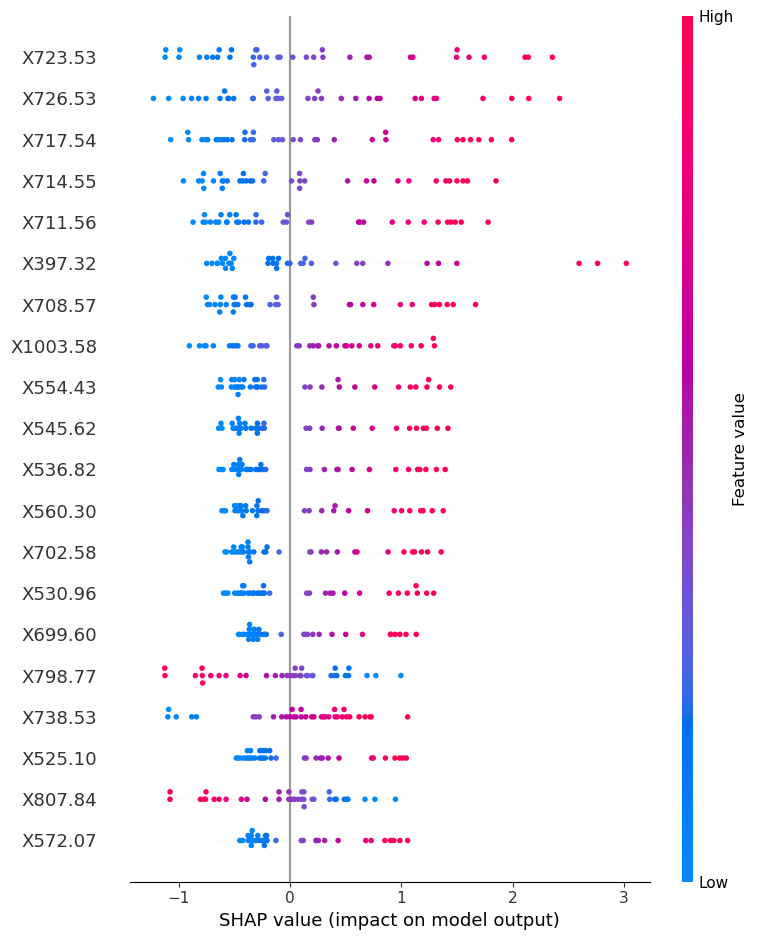

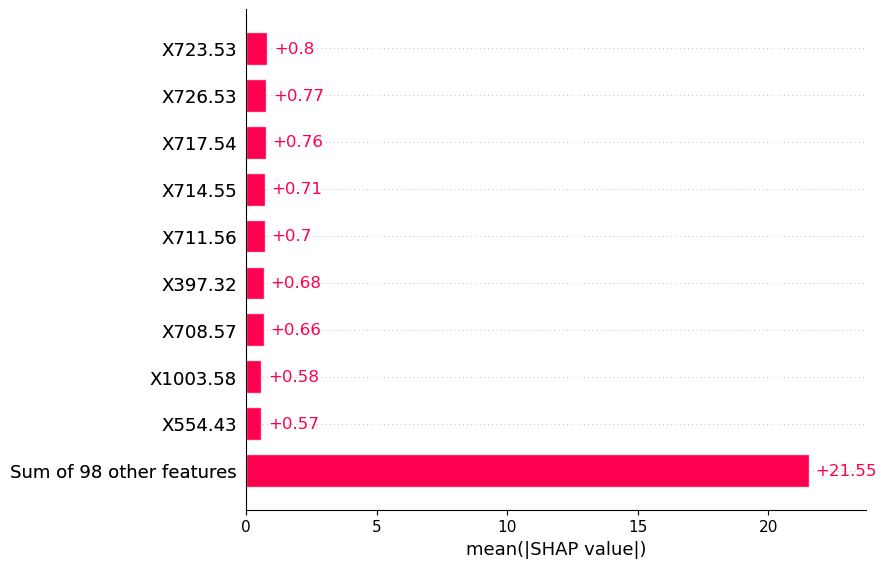

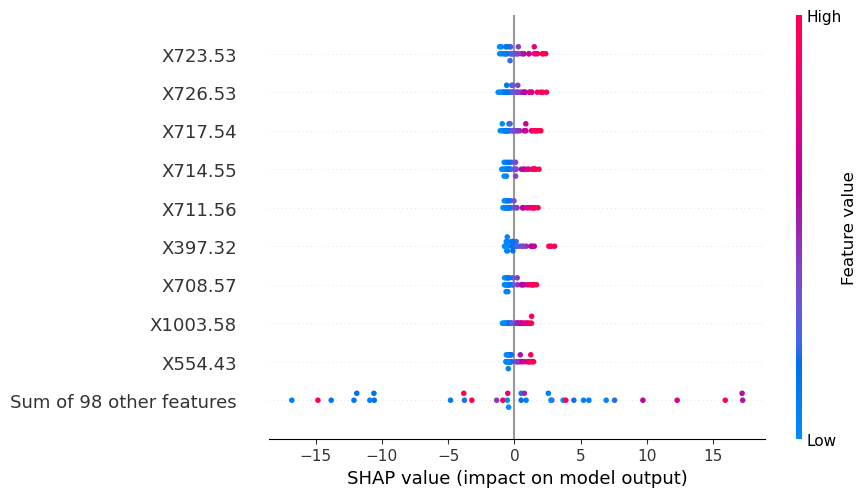

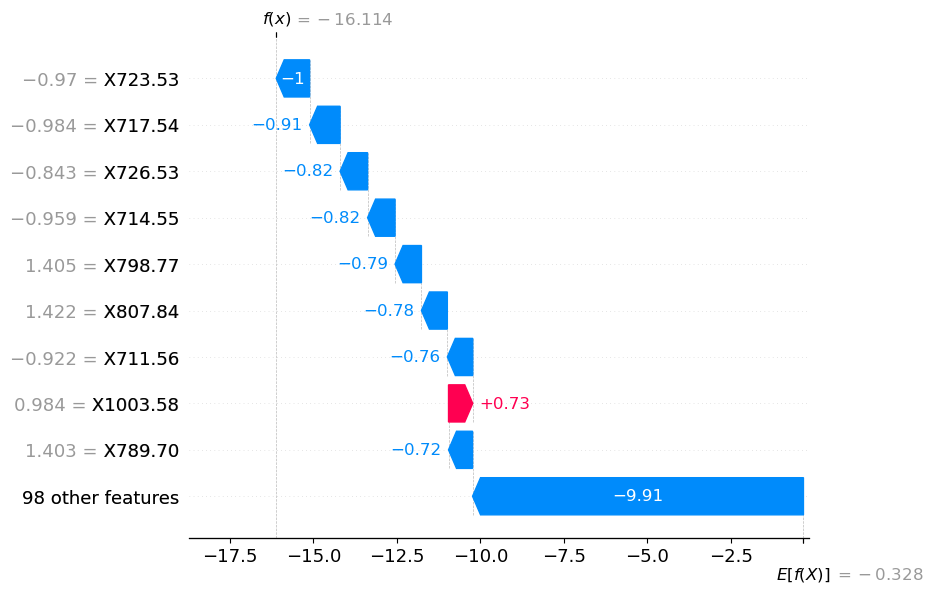

Generating SHAP plots for Class: +N-Fe_Hv


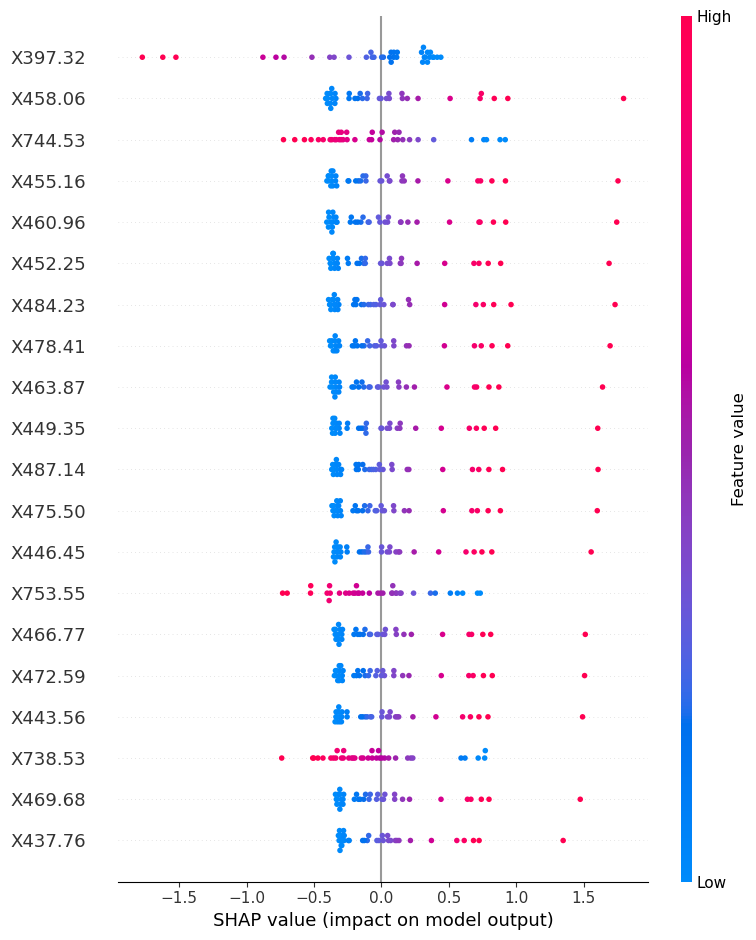

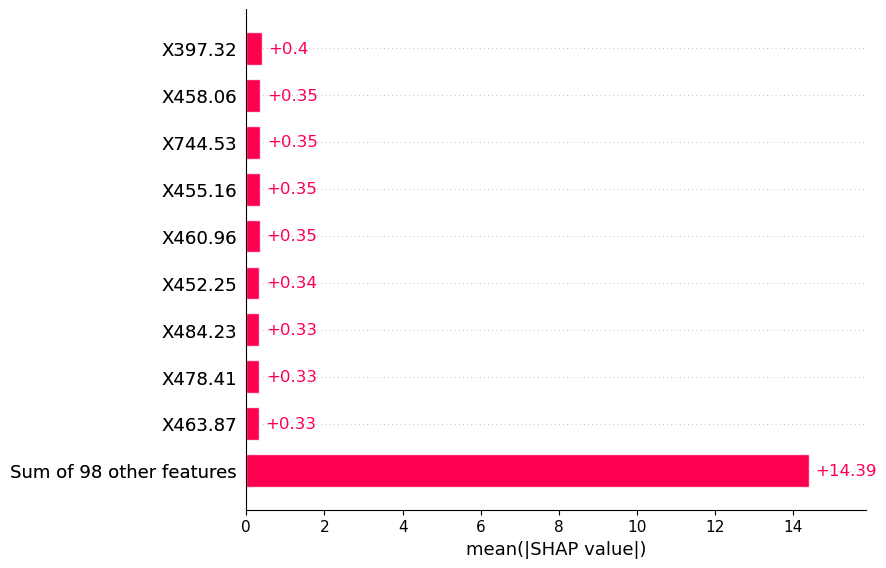

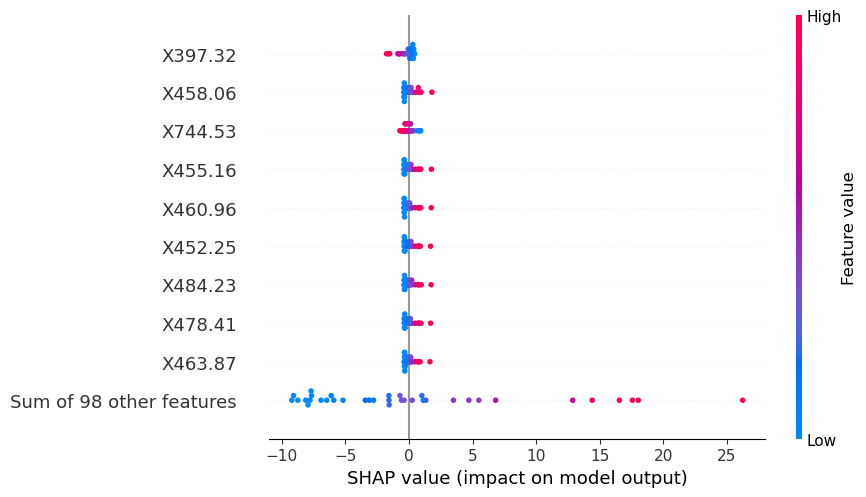

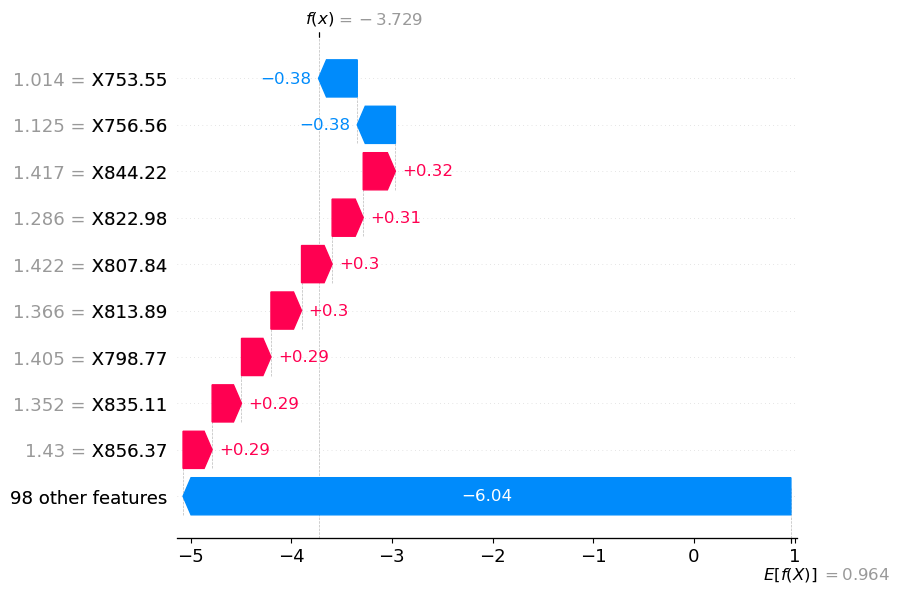

Generating SHAP plots for Class: +N-Fe_Sl


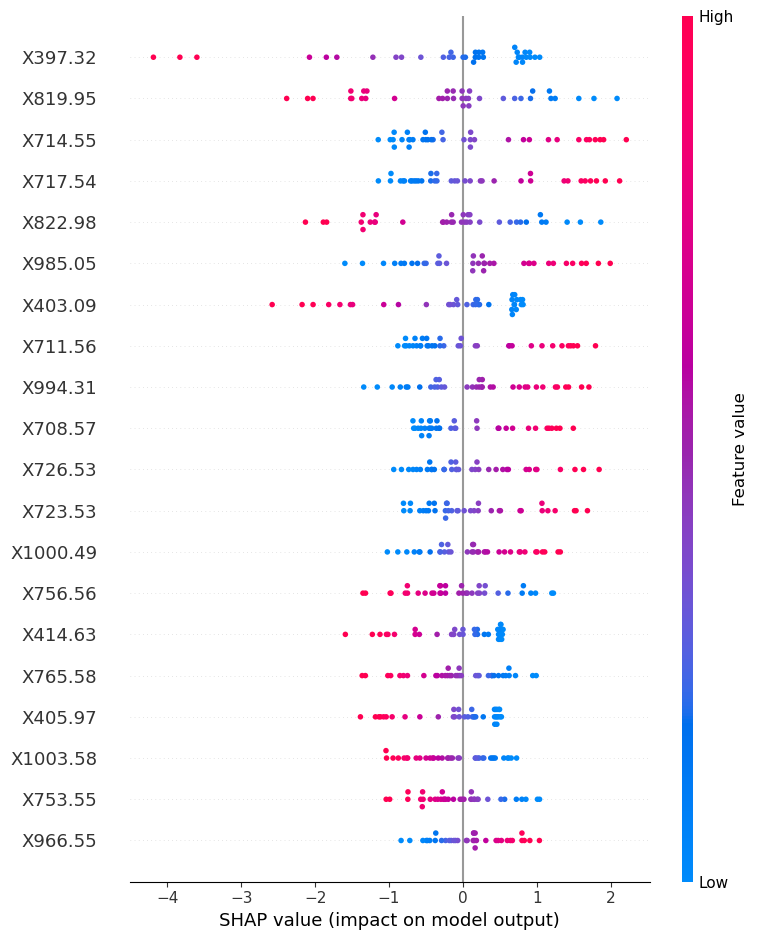

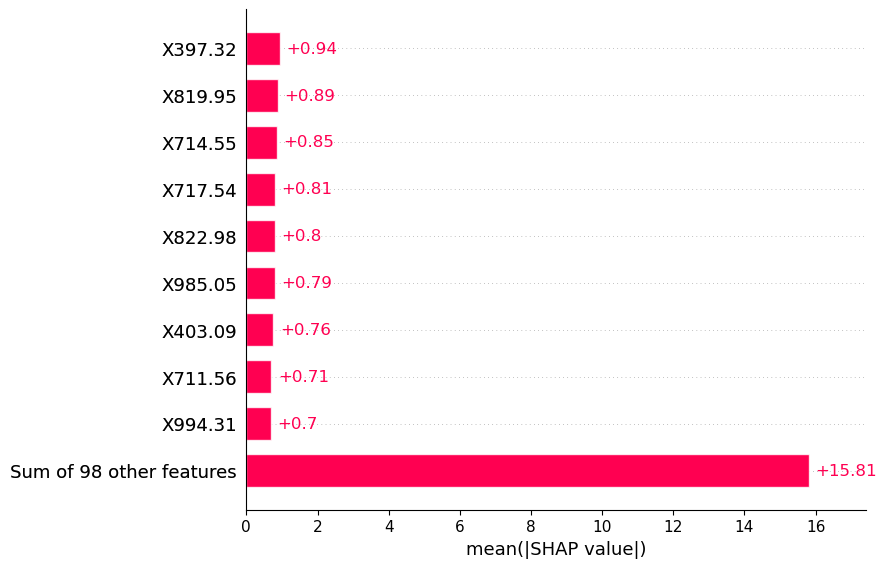

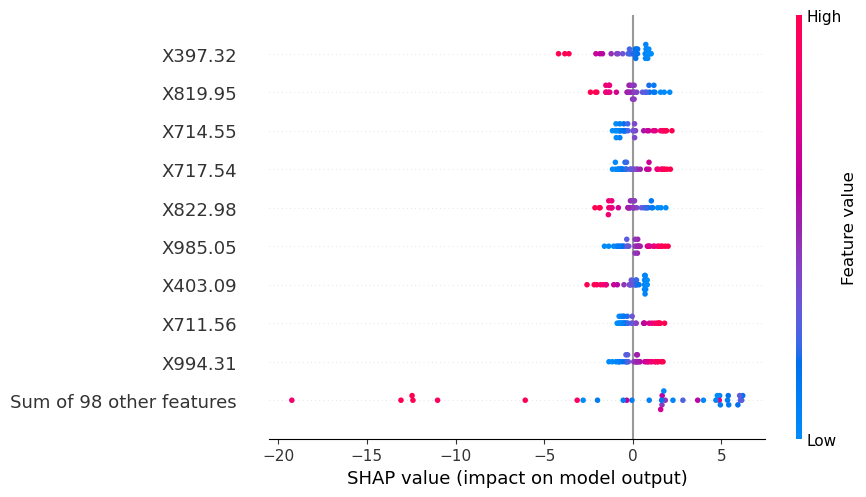

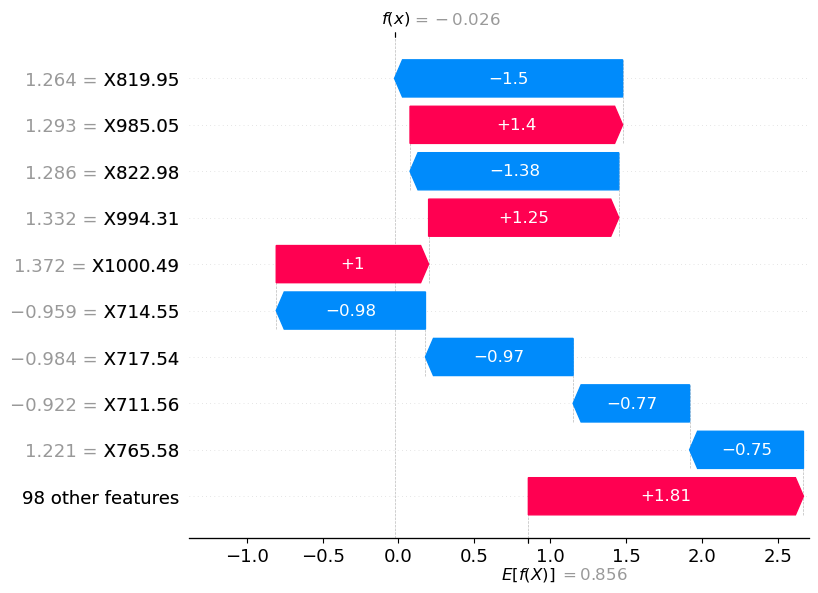

Generating SHAP plots for Class: +N-Fe_Zm


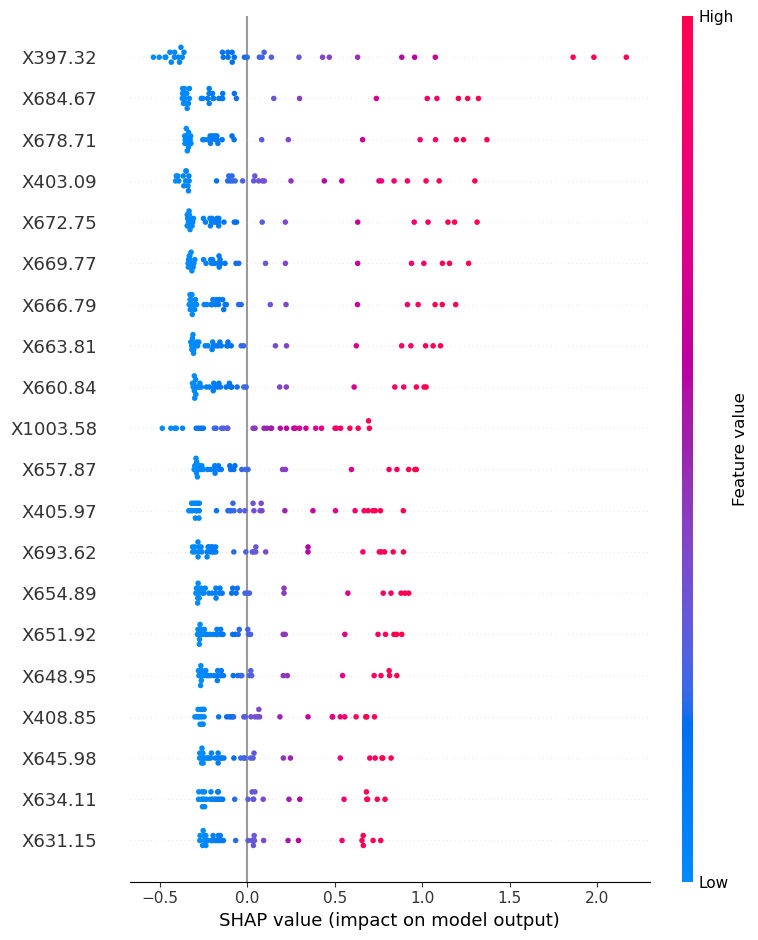

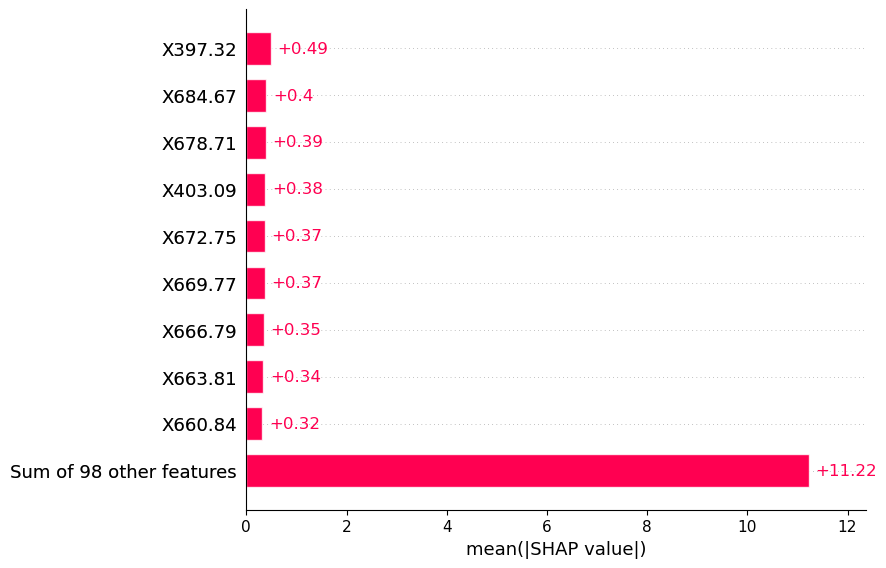

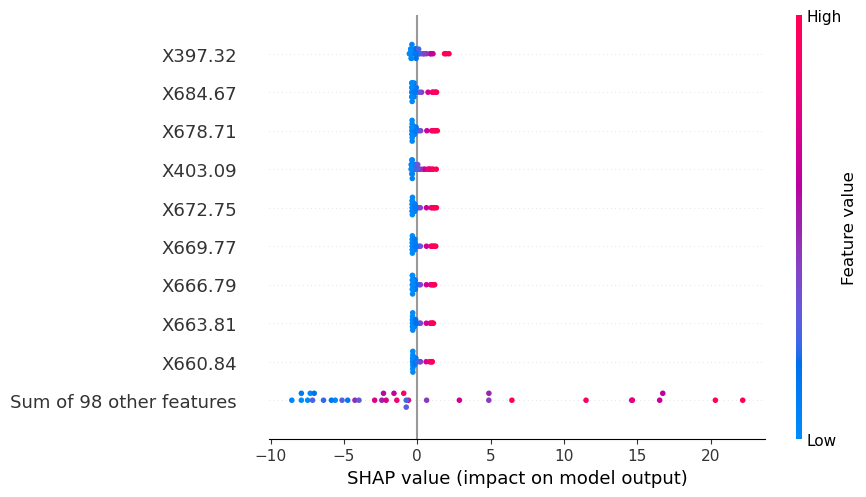

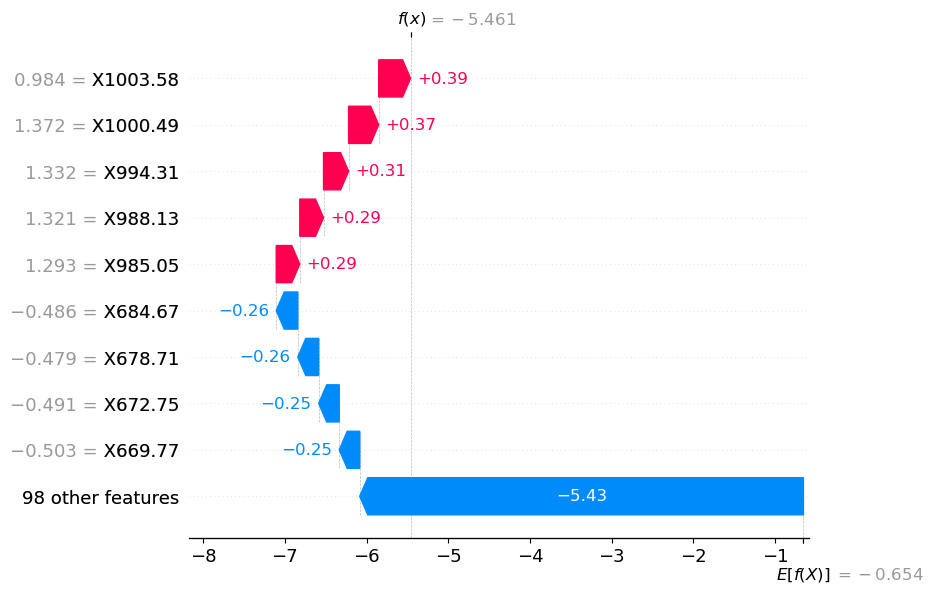

In [10]:
# Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
}
random_state = 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state), 
                              param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# Perform cross-validation
cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
# y_pred_proba = model.predict_proba(X_test)  # Get the predicted probabilities

# Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred))

# # Print the predicted probabilities for the first few instances in the test set
# print("\nPredicted Probabilities (first 5 instances):")
# print(y_pred_proba.shape)
# print(y_pred_proba[:5])
      
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




# SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Check the shape of shap_values
print(shap_values.shape)  # Should output (number_of_samples, number_of_features, number_of_classes)

# Generate all SHAP plots for each class
for i in range(shap_values.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Summary Plot
    shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names, class_names=le.classes_)
    # shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names_reduced, class_names=le.classes_)
    # Bar Plot
    shap.plots.bar(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names), max_display=10)
    # shap.plots.bar(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names_reduced), max_display=10)
    # Beeswarm Plot
    shap.plots.beeswarm(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names))
    # shap.plots.beeswarm(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names_reduced))
    # Waterfall Plot for the first instance
    shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, i], base_values=shap_values.base_values[0, i], data=X_test[0], feature_names=feature_names))
    # shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, i], base_values=shap_values.base_values[0, i], data=X_test[0], feature_names=feature_names_reduced))

#### <font color=green> <font color=green> <font color=red> Multi-Class </font> Polynomial Logistic Regression </font>

Best parameters for Polynomial Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.925974        0.022511   
1          0.925974        0.022511   
2          0.908225        0.049008   
3          0.880087        0.035105   
4          0.935498        0.021576   
5          0.945022        0.033910   
6          0.935498        0.021576   
7          0.926407        0.021208   
8          0.926407        0.035724   
9          0.935065        0.023029   
10         0.935498        0.021576   
11         0.926407        0.021208   
12         0.879654        0.048140   
13         0.925541        0.038345   
14         0.935498        0.021576   
15         0.926407        0.021208   
16         0.888745        0.037002   
17         0.925541        0.038345   
18         0.935498        0.021576   
19         0.926407        0.021208   

                                

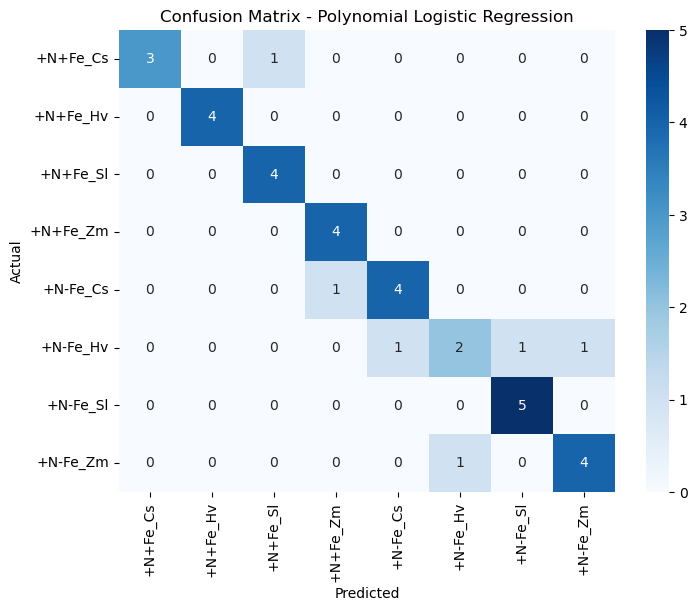

In [6]:
### Polynomial Logistic Regression ###
# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_train)

# Hyperparameter Tuning and Cross-Validation for Polynomial Logistic Regression
param_grid_poly = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
}
random_state = 42
grid_search_poly = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state), param_grid_poly, cv=5, scoring='accuracy')
grid_search_poly.fit(X_poly, y_train)
best_params_poly = grid_search_poly.best_params_
print("Best parameters for Polynomial Logistic Regression:", best_params_poly)

# Print Cross-Validation Scores from GridSearchCV
cv_results_poly = pd.DataFrame(grid_search_poly.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_poly[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best polynomial logistic regression model
model_poly = LogisticRegression(**best_params_poly,max_iter=5000, tol=1e-3,random_state=random_state)

# Train the model on the entire training set
model_poly.fit(X_poly, y_train)

# Make predictions on the test set
y_pred_poly = model_poly.predict(poly.transform(X_test))

# Model Evaluation for Polynomial Logistic Regression
print("\nPolynomial Logistic Regression - Test Set Accuracy:", accuracy_score(y_test, y_pred_poly))
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_poly))

# Confusion Matrix
conf_matrix_poly = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_poly, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Polynomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### <font color=green> <font color=red> Multi-Class </font> Random Forest </font>

Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.908225        0.069865   
1           0.899134        0.066102   
2           0.908225        0.069865   
3           0.917316        0.052422   
4           0.880952        0.073005   
..               ...             ...   
283         0.898701        0.043858   
284         0.890043        0.067820   
285         0.907792        0.049427   
286         0.907792        0.049427   
287         0.917316        0.060457   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

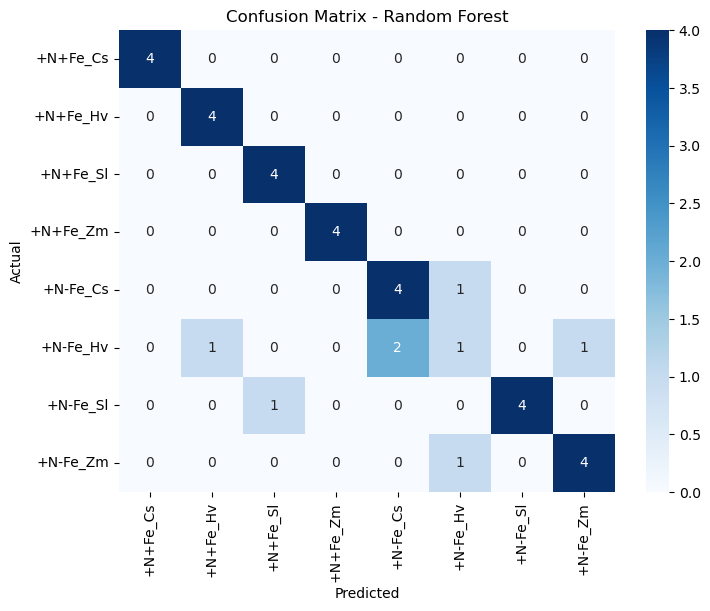

Random Forest shap_values shape is (36, 107, 8)
SHAP values shape: (36, 107, 8)
Generating SHAP plots for Class: +N+Fe_Cs


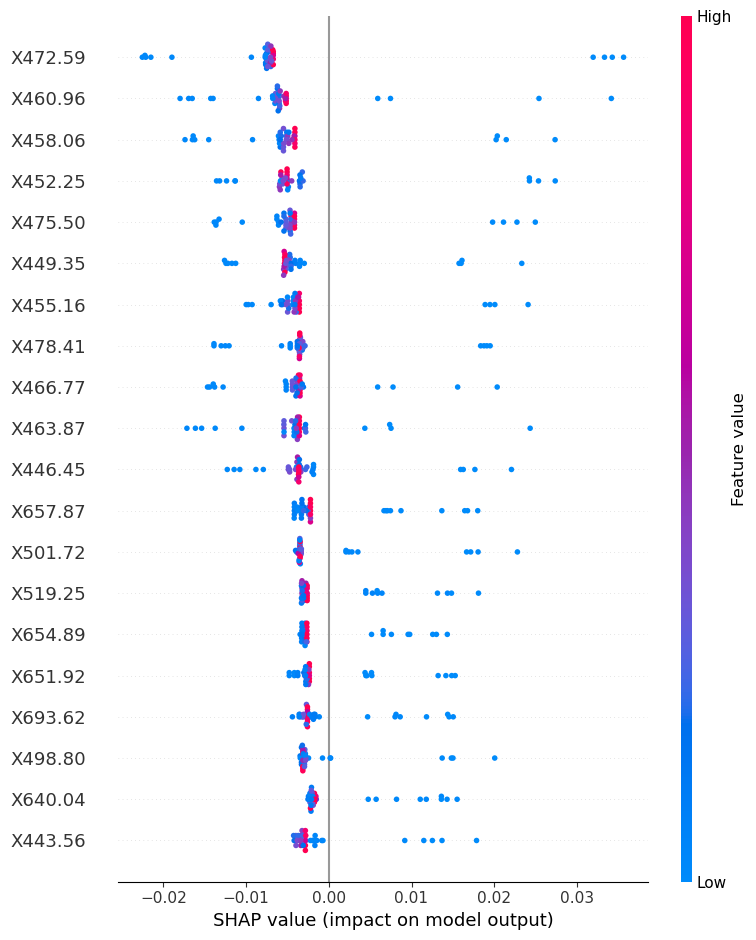

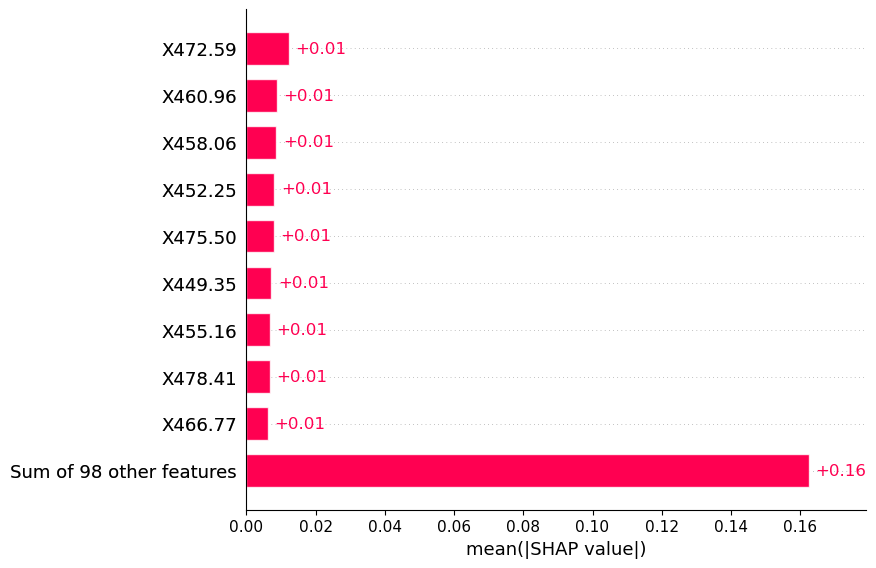

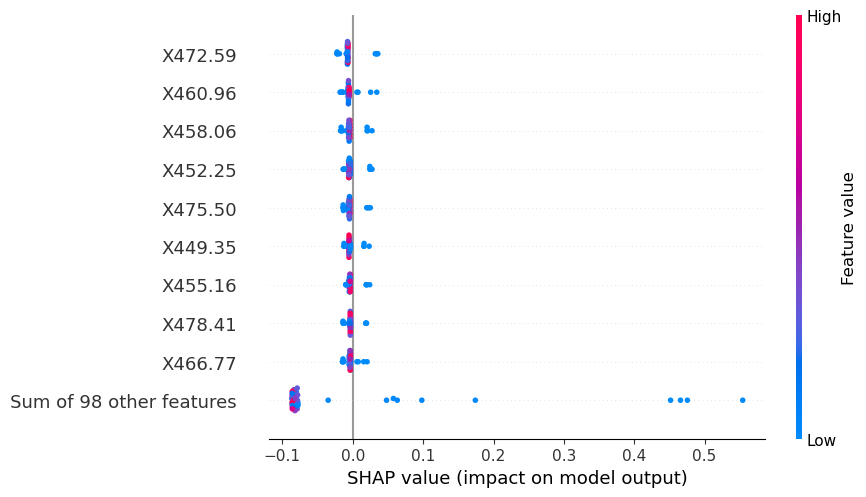

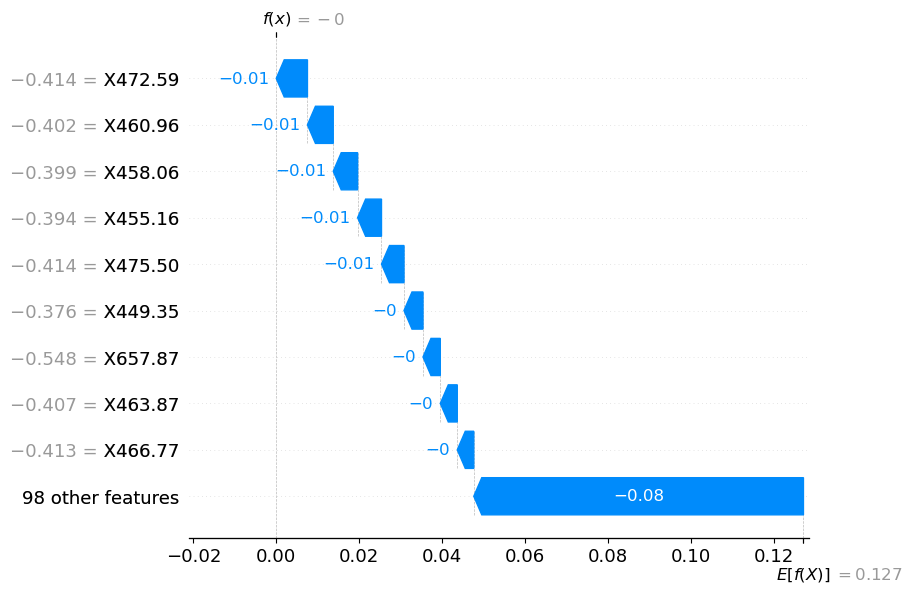

Generating SHAP plots for Class: +N+Fe_Hv


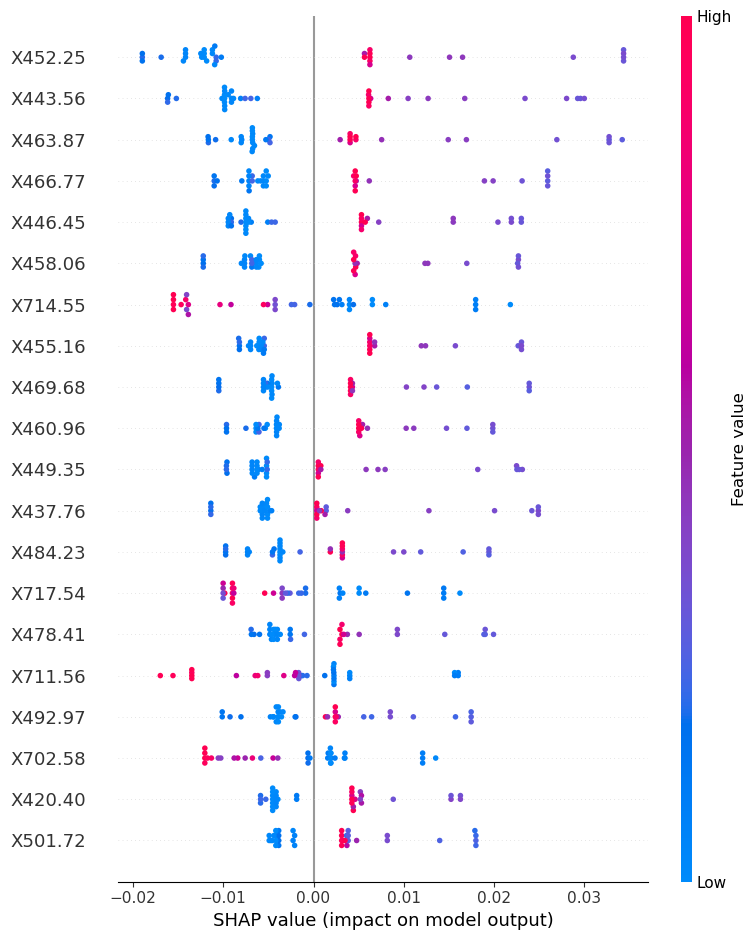

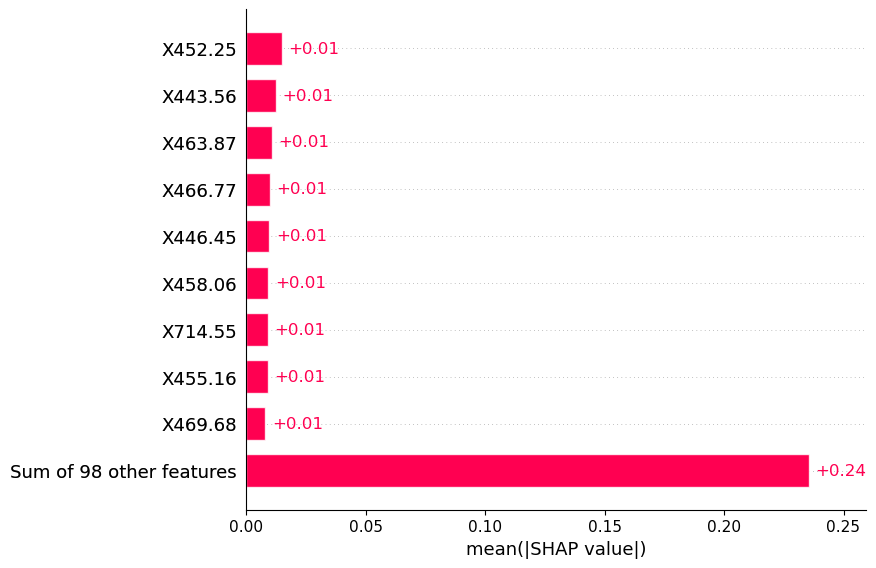

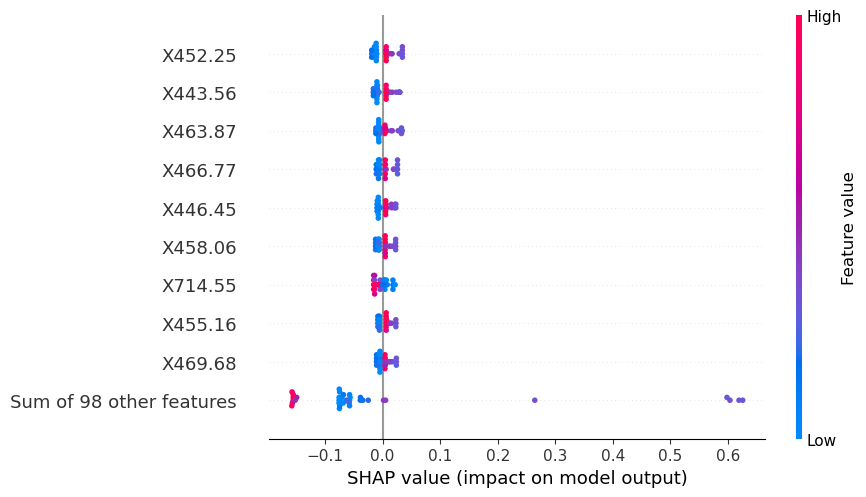

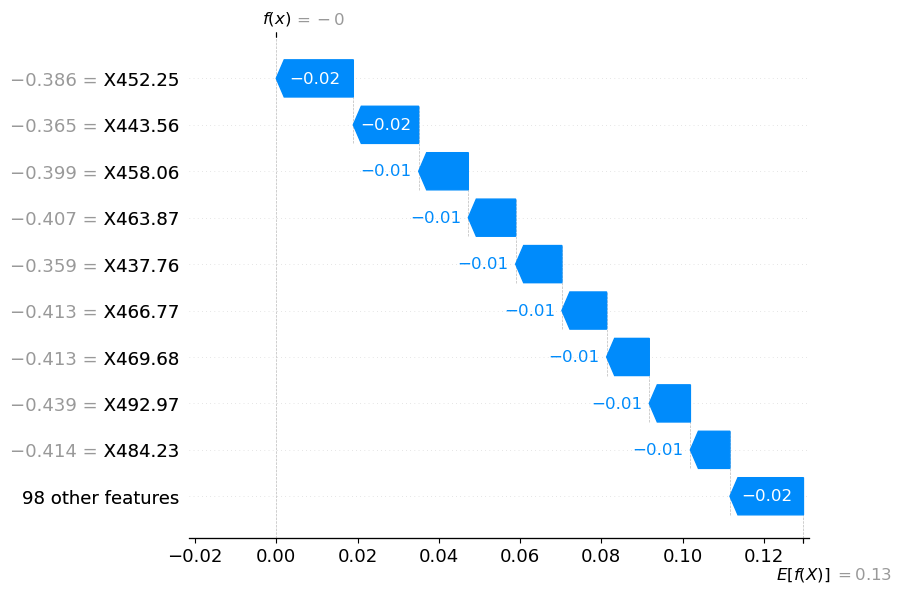

Generating SHAP plots for Class: +N+Fe_Sl


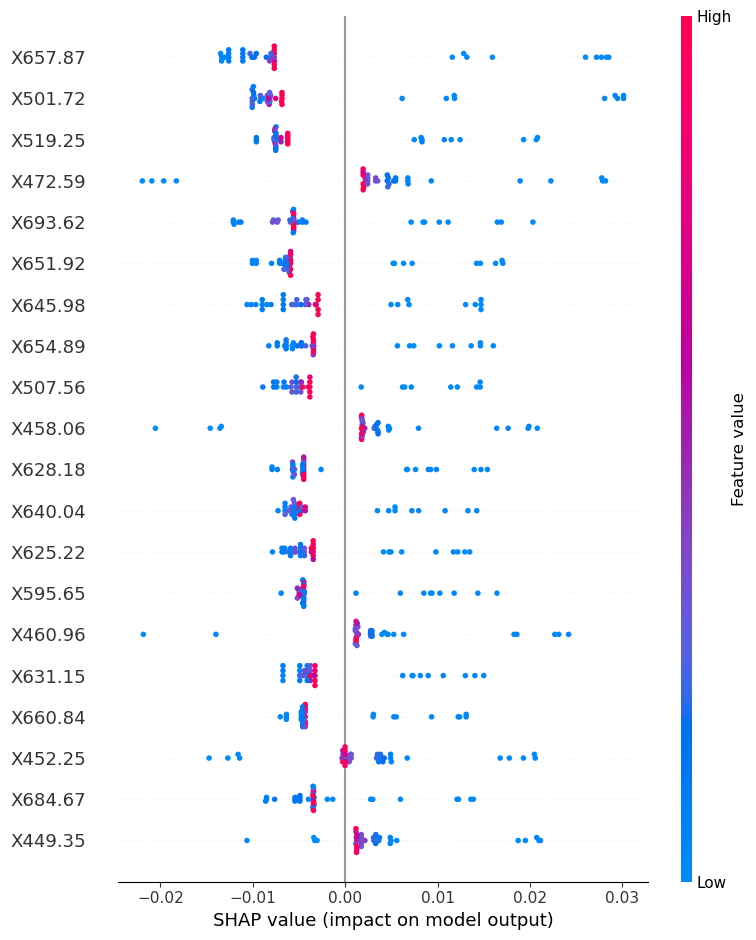

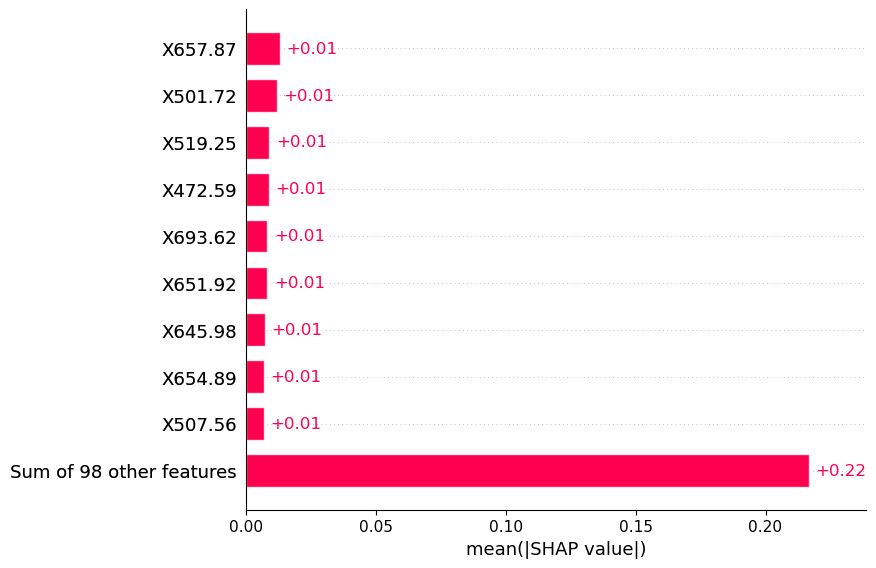

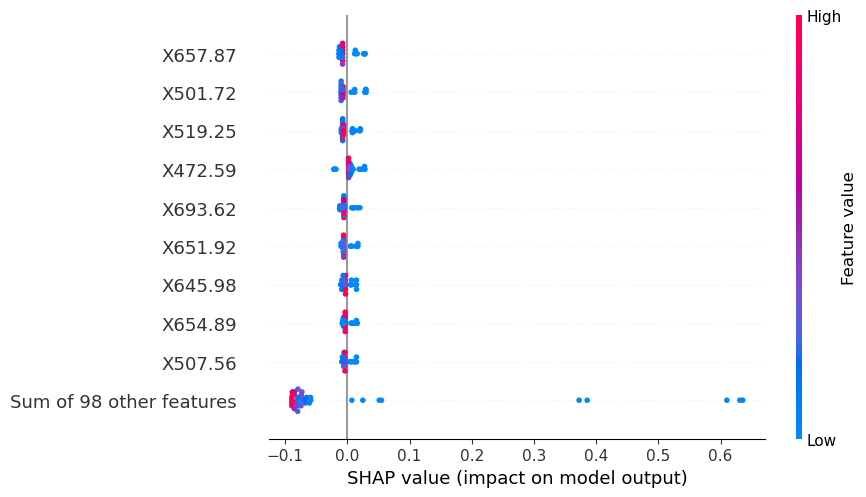

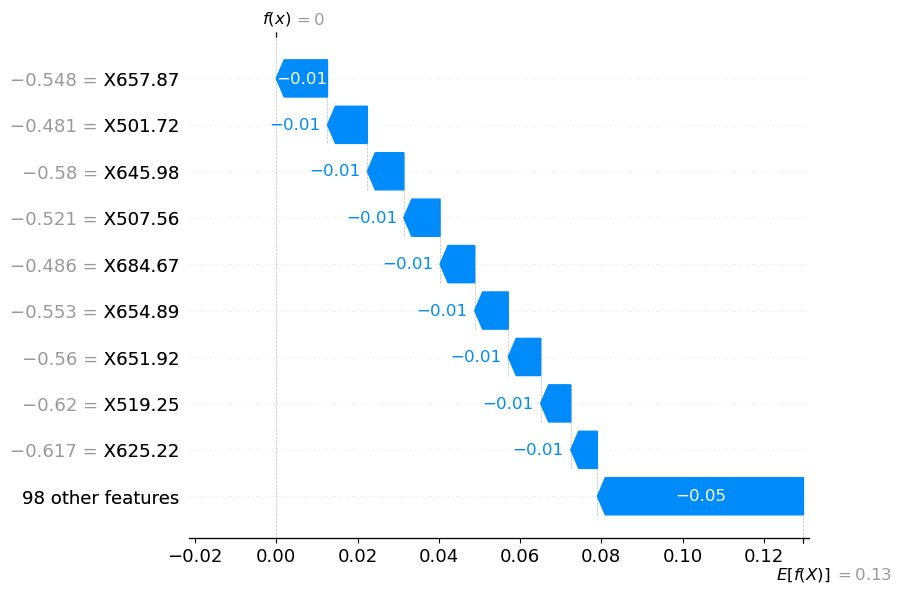

Generating SHAP plots for Class: +N+Fe_Zm


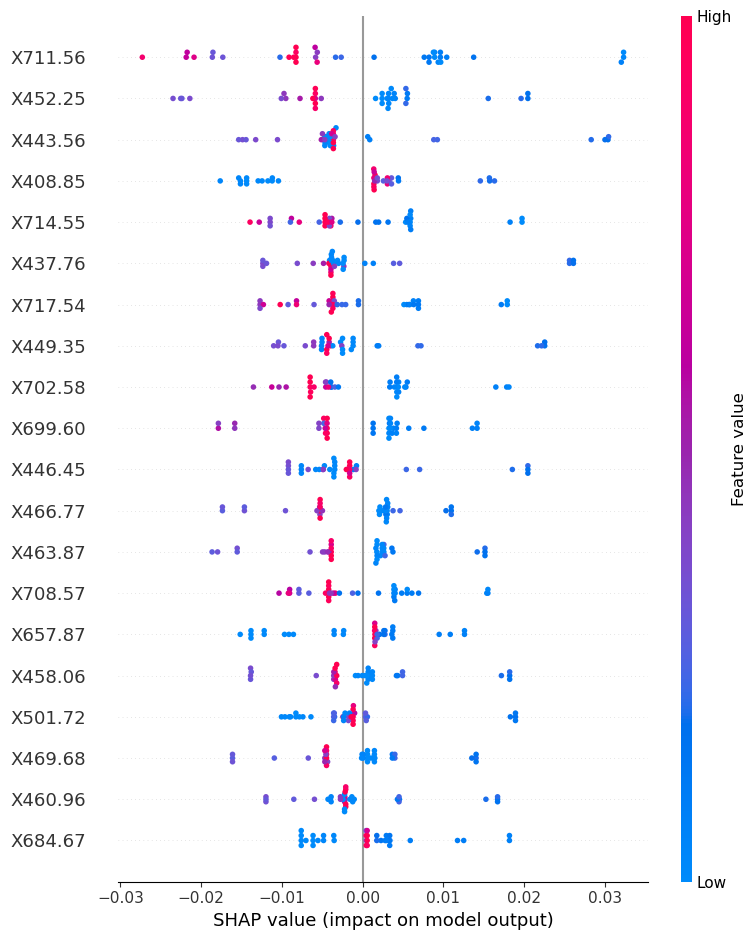

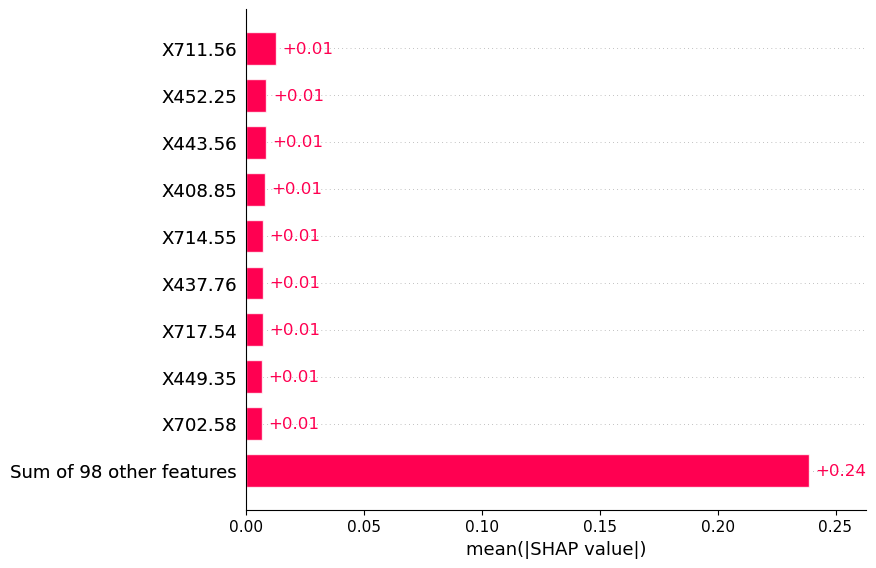

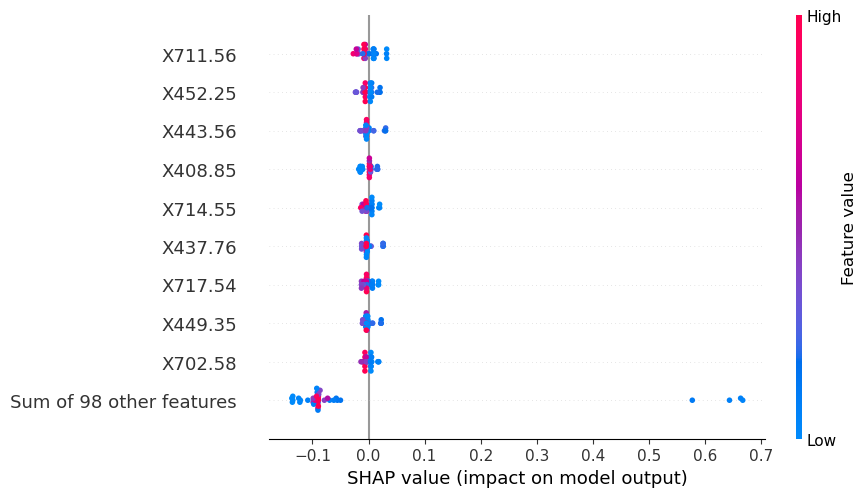

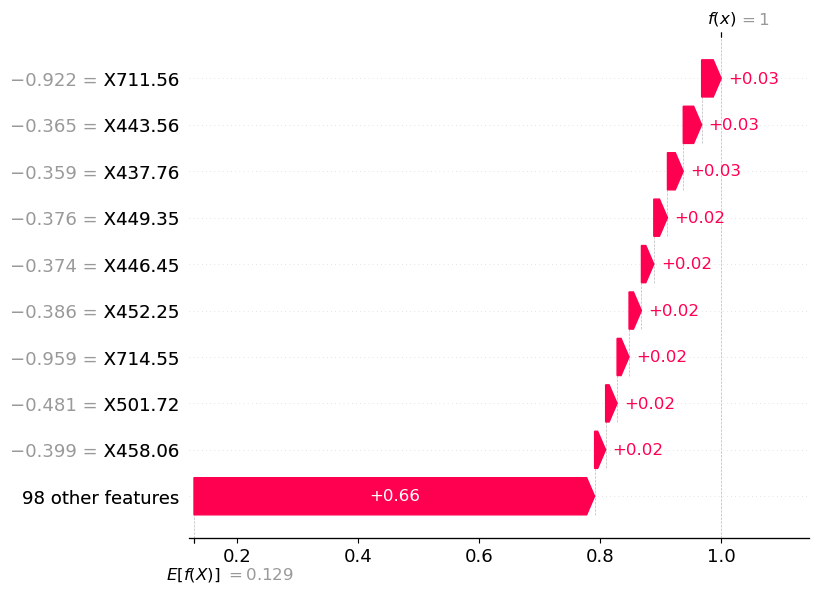

Generating SHAP plots for Class: +N-Fe_Cs


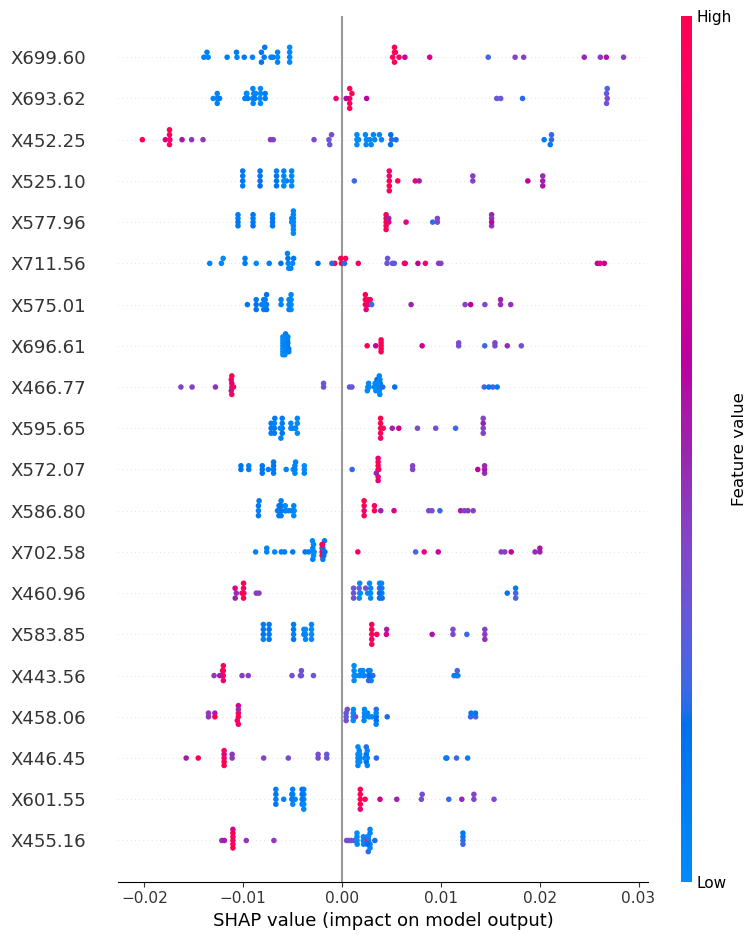

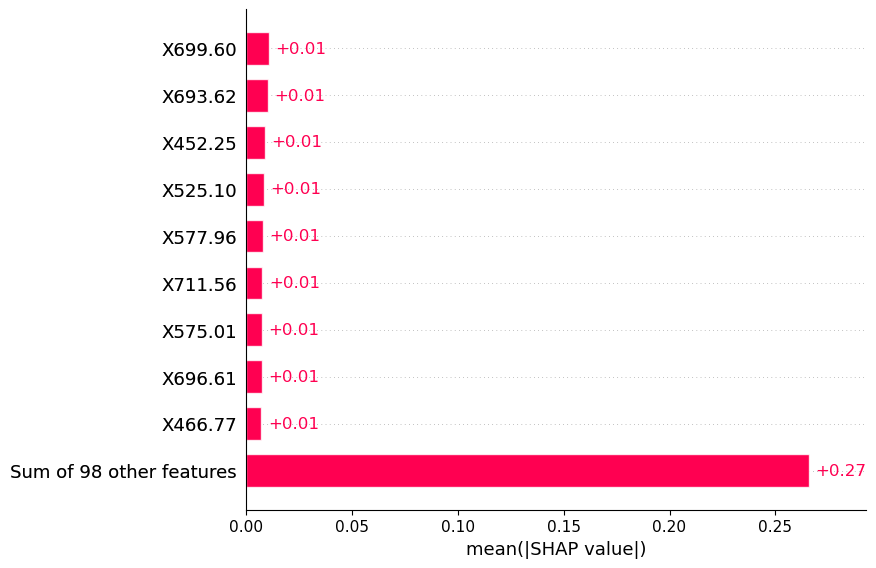

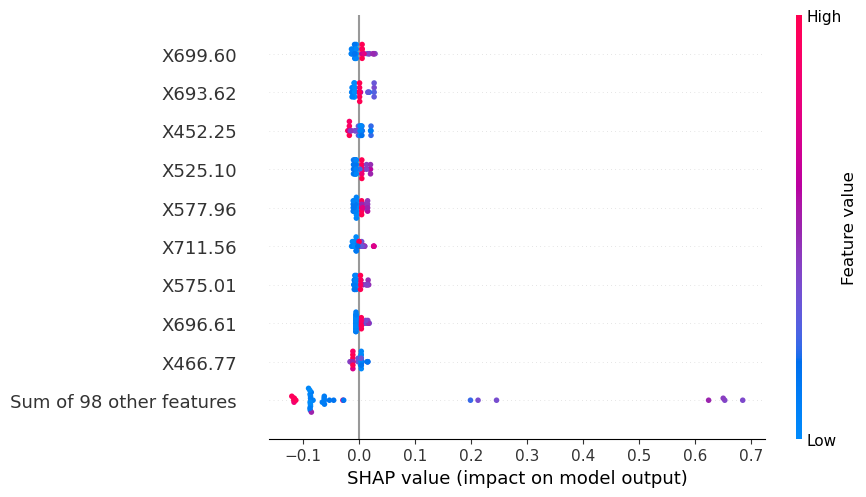

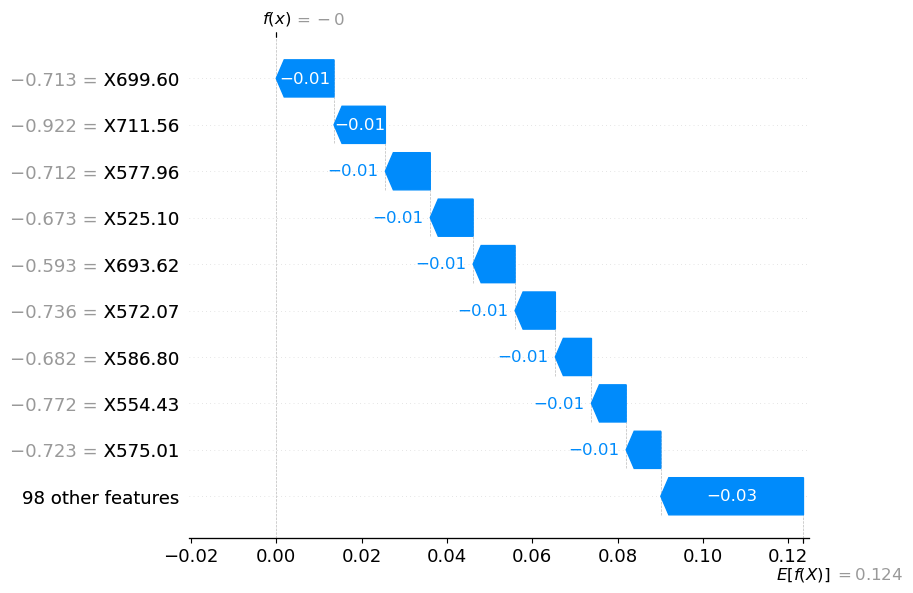

Generating SHAP plots for Class: +N-Fe_Hv


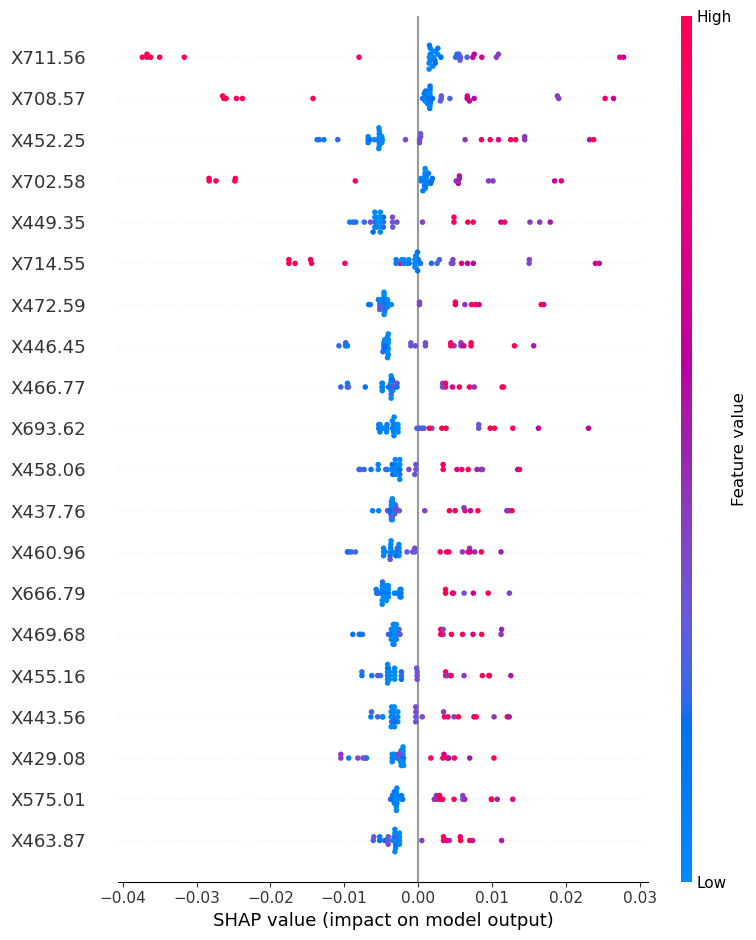

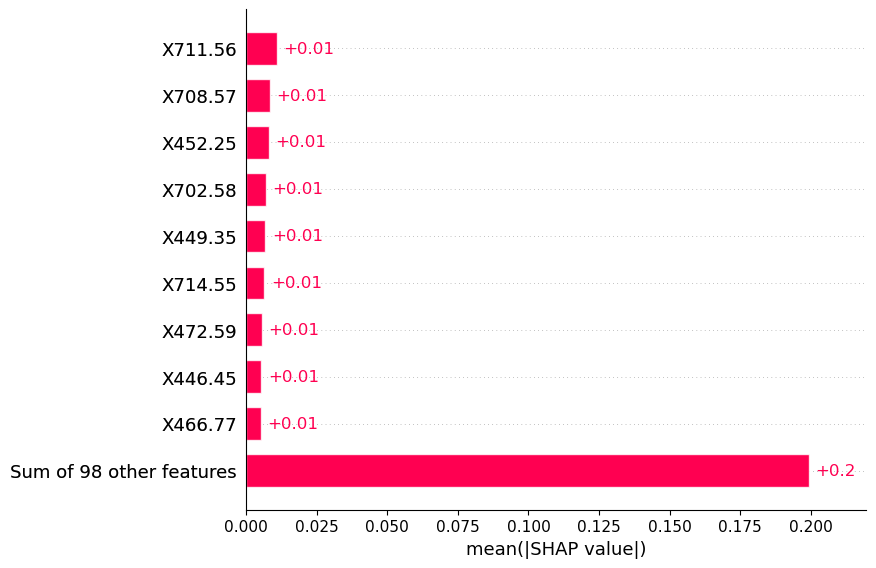

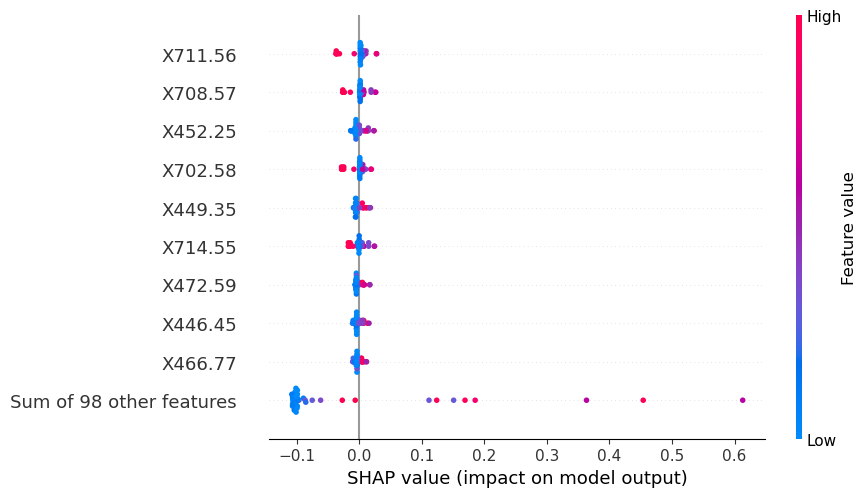

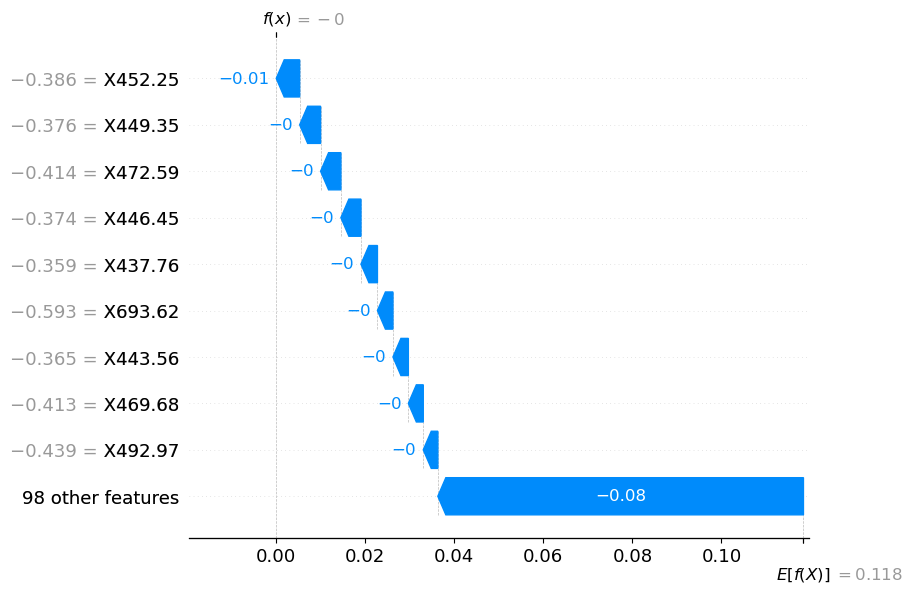

Generating SHAP plots for Class: +N-Fe_Sl


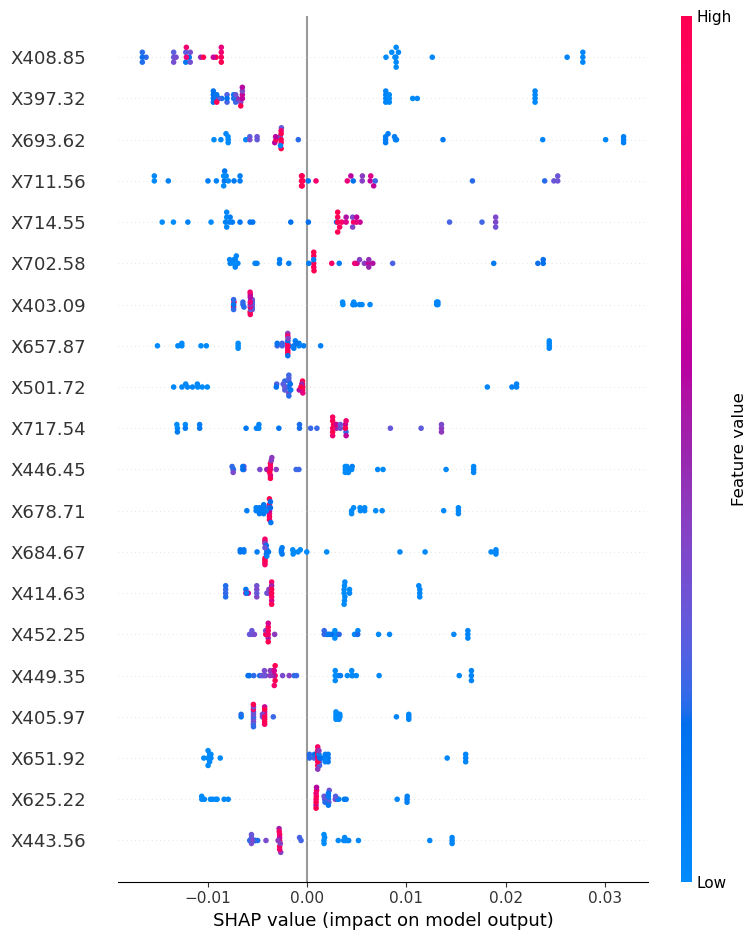

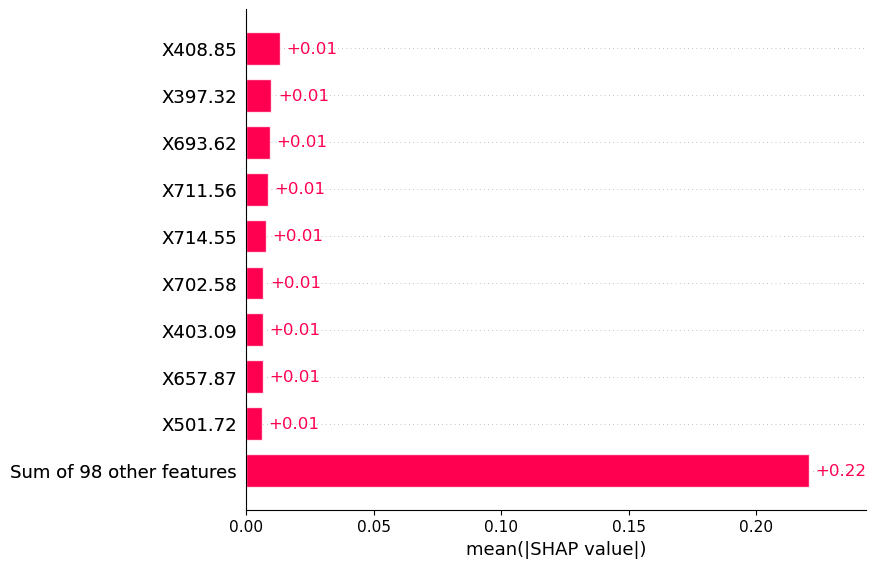

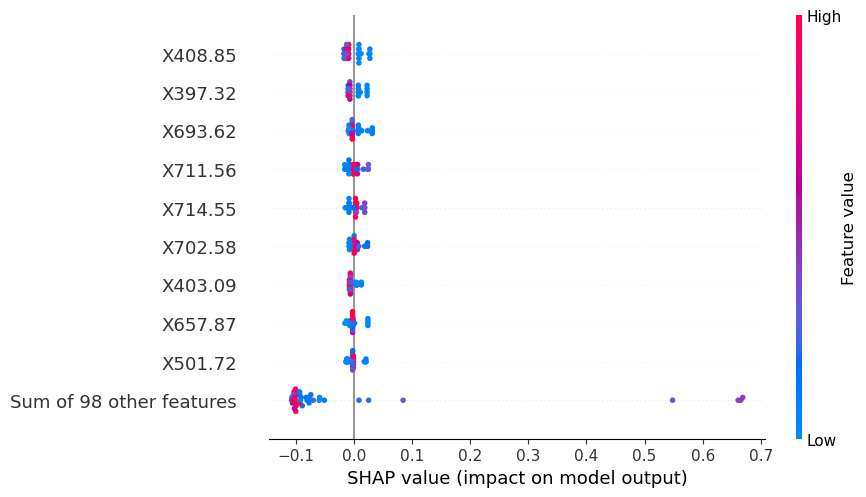

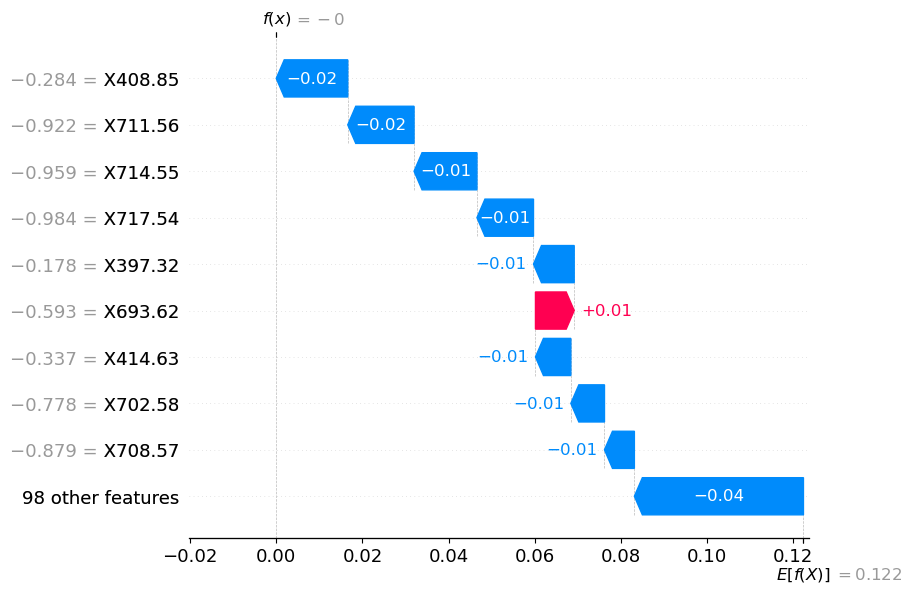

Generating SHAP plots for Class: +N-Fe_Zm


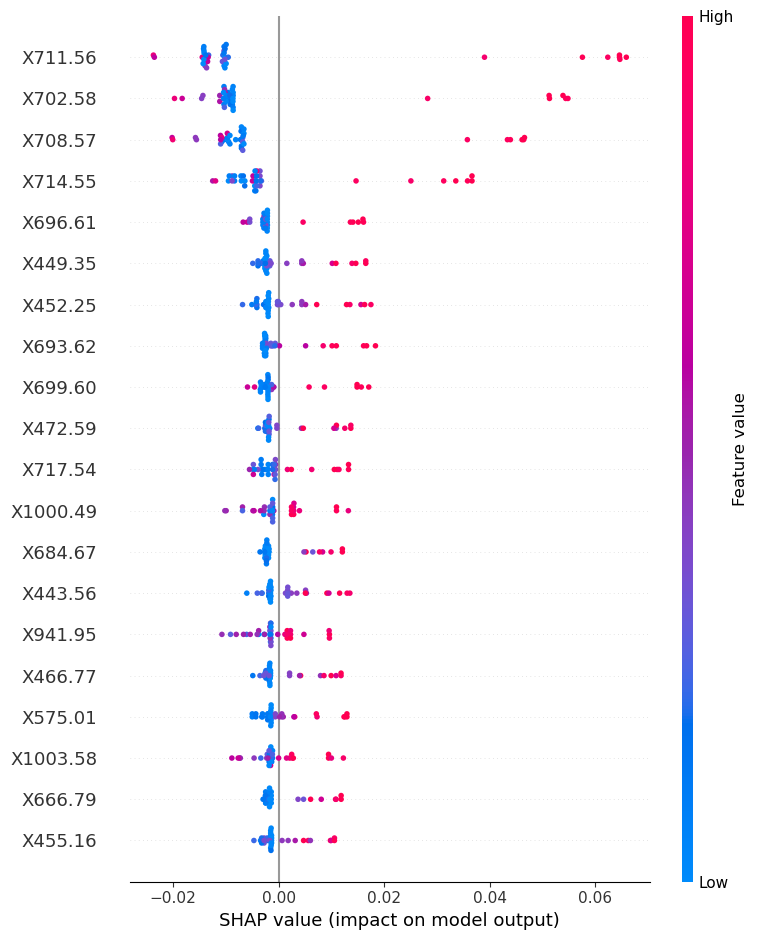

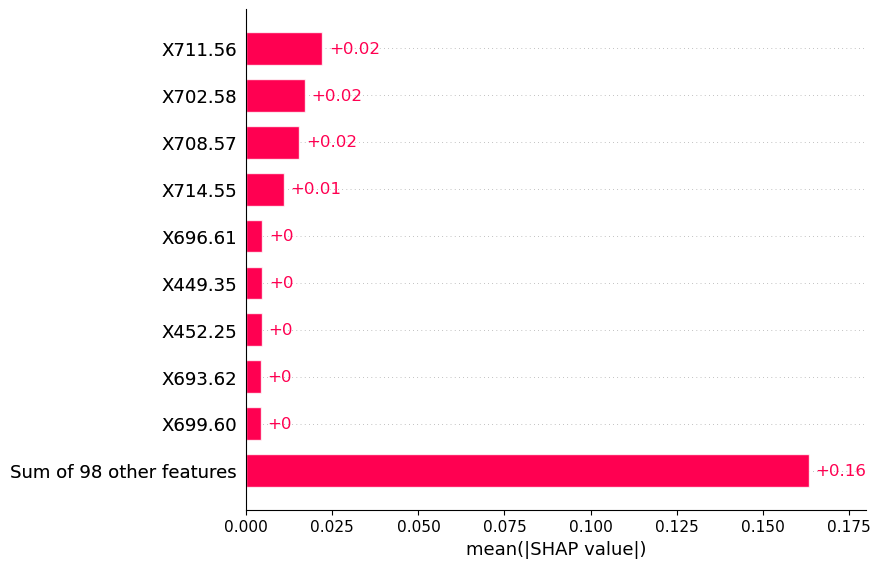

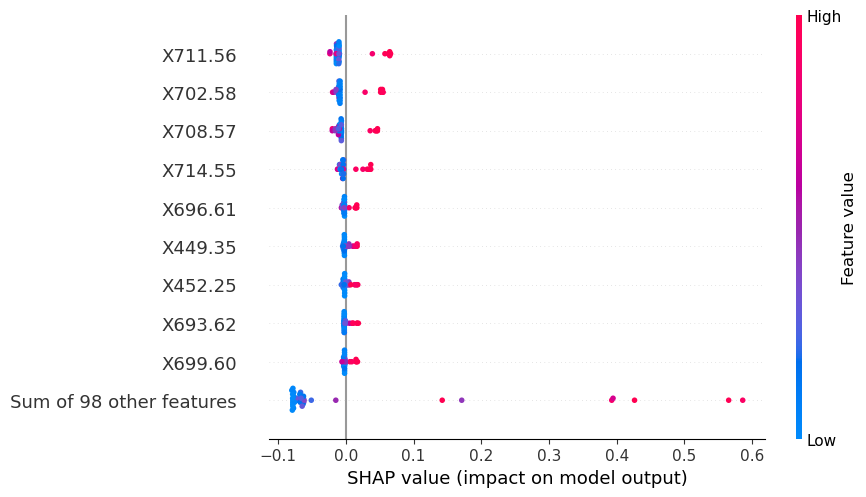

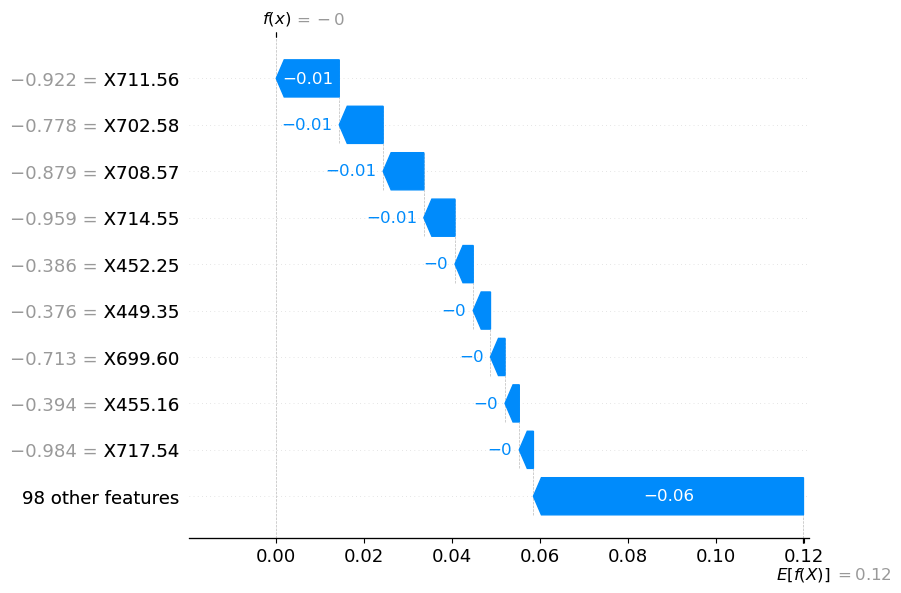

In [10]:
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_rf))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_test)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))  # Should output (number_of_classes, number_of_samples, number_of_features)

# Ensure X_test is an array
X_test_array = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
# Check the shape of shap_values_rf
print("SHAP values shape:", shap_values_rf.shape)

# Generate all SHAP plots for each class
for i in range(shap_values_rf.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Ensure the shapes match for the summary plot
    class_shap_values = shap_values_rf[:, :, i]
    
    # Create an Explanation object for the current class
    shap_explanation = shap.Explanation(
        values=class_shap_values,  # SHAP values for class i
        base_values=explainer_rf.expected_value[i],  # Base values for class i
        data=X_test_array,
        feature_names=feature_names_reduced
        # feature_names=feature_names
    )

    # Summary Plot
    # shap.summary_plot(shap_explanation, X_test_array, feature_names=feature_names, class_names=le.classes_)
    shap.summary_plot(shap_explanation, X_test_array, feature_names=feature_names_reduced, class_names=le.classes_)
    # Bar Plot
    shap.plots.bar(shap_explanation, max_display=10)

    # Beeswarm Plot
    shap.plots.beeswarm(shap_explanation)

    # Waterfall Plot for the first instance
    shap.plots.waterfall(shap_explanation[0])
